# Proyecto Final — Analítica y Visualización de Datos
## Calidad del aire en la Zona Metropolitana del Valle de México (RAMA / SIMAT)

**Integrantes:**
- García Juanillo Alan
- Reyes León Angel Eduardo

**Grupo:** 5AM1 · Licenciatura en Ciencia de Datos · ESCOM — IPN

## 1. Introducción

**Contexto.** La Ciudad de México y su zona conurbada concentran a más de 20 millones de personas en una cuenca rodeada de montañas que dificulta la dispersión de los contaminantes atmosféricos. Desde 1986, la Red Automática de Monitoreo Atmosférico (**RAMA**) del Sistema de Monitoreo Atmosférico (SIMAT, SEDEMA) mide cada hora las concentraciones de los contaminantes criterio —ozono (O$_3$), partículas PM$_{10}$ y PM$_{2.5}$, dióxido de nitrógeno (NO$_2$), dióxido de azufre (SO$_2$) y monóxido de carbono (CO)— en decenas de estaciones distribuidas por la ciudad, mientras que la red REDMET registra las variables meteorológicas (temperatura, humedad relativa, viento).

**Problema.** Los datos crudos de la RAMA presentan los retos típicos de cualquier sistema de medición real: huecos por fallas de sensor, códigos de dato inválido ($-99$), valores extremos asociados a contingencias ambientales y ruido de medición. Además, las series tienen estructura periódica (ciclos diurnos y estacionales) y las concentraciones de los distintos contaminantes están relacionadas entre sí y con la meteorología. Esto plantea las preguntas que guían el proyecto: *¿qué patrones periódicos gobiernan la contaminación del aire en la ciudad?, ¿qué estaciones de monitoreo se comportan de manera similar?, ¿qué relación existe entre los contaminantes y las variables meteorológicas, y entre la calidad del aire y la temporada del año?*

**Justificación.** Este dataset permite aplicar, sobre un caso real y de relevancia directa para los habitantes de la ciudad, la totalidad de las técnicas vistas en el curso: el **preprocesamiento** (muestreo, manejo de errores, imputación, filtrado, transformación — Unidad I), los **métodos de proyección y el análisis espectral** (PCA, MDS, transformada del seno y coseno — Unidad II) y el **análisis de correlación** lineal y no lineal (Pearson, Spearman, Kendall y chi-cuadrada — Unidad III), integrando los resultados en un tablero interactivo (Unidad II, tema 2.4).

## 2. Objetivos

**Objetivo general.** Aplicar técnicas de preprocesamiento, análisis y visualización de datos a las mediciones horarias de la RAMA para caracterizar el comportamiento temporal y espacial de la contaminación atmosférica en el Valle de México, y comunicar los resultados mediante un tablero interactivo en Streamlit.

**Objetivos específicos.**
1. Integrar y limpiar las bases horarias de contaminantes y meteorología: identificar datos inválidos, imputar valores ausentes y detectar outliers, verificando visualmente cada paso.
2. Suavizar las series de tiempo con los filtros vistos en clase (medias móviles, medianas móviles y filtro exponencial) y comparar su comportamiento.
3. Identificar las componentes periódicas de las series mediante el análisis espectral (transformada discreta del seno y coseno) y reconstruir las series a partir de sus componentes dominantes.
4. Caracterizar la similitud entre estaciones de monitoreo mediante PCA y MDS, contrastando la implementación propia con la de `scikit-learn`.
5. Cuantificar la relación entre contaminantes y meteorología con los coeficientes de Pearson, Spearman y Kendall, y evaluar la dependencia entre la categoría de calidad del aire y la temporada del año con la prueba chi-cuadrada de independencia.
6. Construir un dashboard en Streamlit que presente los resultados del análisis con filtros interactivos por estación, contaminante y periodo.

## 3. Comprensión de los datos

**Fuente.** Bases de datos horarias anuales del SIMAT, descargadas del portal oficial [aire.cdmx.gob.mx](https://aire.cdmx.gob.mx) (sección *Datos → Descargas*). Cada archivo anual está en **formato largo**: un renglón por (fecha-hora, estación, parámetro).

**Diccionario de variables (archivos crudos):**

| Columna | Tipo | Descripción |
|---|---|---|
| `date` | texto | Fecha y hora local en formato `dd/mm/aaaa HH:MM`. La RAMA usa horas de `01:00` a `24:00` (la hora `24:00` es la medianoche del día siguiente). |
| `id_station` | categórica | Clave de la estación de monitoreo (p. ej. `MER` = Merced, `PED` = Pedregal, `XAL` = Xalostoc). |
| `id_parameter` | categórica | Parámetro medido. Contaminantes: `O3`, `PM10`, `PM2.5`, `NO2`, `SO2`, `CO`. Meteorología: `TMP`, `RH`, `WSP`. |
| `value` | numérica (razón) | Concentración o medición. Vacío o `-99` indica dato inválido. |
| `unit` | categórica | Unidad: ppb, ppm, µg/m³, °C, %, m/s. |

**Escalas de los datos** (apuntes, Unidad I): las concentraciones, la temperatura y el viento están en escala de **razón/intervalo**; la estación, el parámetro y las categorías de calidad del aire que construiremos más adelante son **nominales**; la categoría del índice AIRE Y SALUD (Buena < Aceptable < Mala < Muy mala) es **ordinal**.

> ⚠️ **Nota sobre los datos.** Este notebook es **autónomo**: las siguientes secciones definen todas las funciones e intentan **descargar automáticamente** los datos reales de la RAMA. Si la descarga no es posible (servidor caído o red con restricciones), se generan datos **sintéticos** con el mismo formato solo para que el flujo corra; en ese caso aparece un aviso y, para la entrega final, basta colocar los CSV reales en `datos/crudos/` (o ejecutar en una red sin restricciones) y volver a correr el notebook.

## 4. Configuración del entorno y funciones del proyecto

Como el notebook es autónomo, en esta sección se **importan las librerías** y se **definen todas las funciones** que se usarán: el catálogo de estaciones, la carga de los archivos de la RAMA y —lo más importante para la materia— las **implementaciones desde cero de las técnicas del curso** (filtros, transformada del seno y coseno, prueba chi-cuadrada). A lo largo del proyecto, las librerías como `scikit-learn` se usan únicamente para *verificar* estas implementaciones, nunca para sustituirlas.

In [ ]:
import glob, json, gzip
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")

# Carpetas de datos (relativas a la ubicación del notebook)
RUTA_CRUDOS = Path("datos/crudos");     RUTA_CRUDOS.mkdir(parents=True, exist_ok=True)
RUTA_PROC   = Path("datos/procesados"); RUTA_PROC.mkdir(parents=True, exist_ok=True)

# --- Configuración de datos ---
ANIOS = [2024, 2025, 2026]   # most recent years available on the RAMA portal
PERMITIR_EJEMPLO = True   # si la descarga falla, generar datos sintéticos para probar
print("Librerías cargadas. Carpetas de datos listas.")

Librerías cargadas. Carpetas de datos listas.


### 4.1 Catálogo de estaciones y parámetros

In [ ]:
# Catálogo de estaciones de la RAMA (clave -> nombre, zona del Valle de México)
# Fuente: catálogo oficial del SIMAT (cat_estacion.csv).
ESTACIONES = {
    "ACO": ("Acolman", "NE"),                     "AJM": ("Ajusco Medio", "SO"),
    "AJU": ("Ajusco", "SO"),                      "ATI": ("Atizapán", "NO"),
    "BJU": ("Benito Juárez", "CE"),               "CAM": ("Camarones", "NO"),
    "CCA": ("Centro Ciencias Atmósfera", "SO"),   "CHO": ("Chalco", "SE"),
    "COY": ("Coyoacán", "SO"),                    "CUA": ("Cuajimalpa", "SO"),
    "CUT": ("Cuautitlán", "NO"),                  "FAC": ("FES Acatlán", "NO"),
    "FAR": ("FES Aragón", "NE"),                  "GAM": ("Gustavo A. Madero", "NE"),
    "HGM": ("Hospital General", "CE"),            "INN": ("Inv. Nucleares", "SO"),
    "IZT": ("Iztacalco", "CE"),                   "LLA": ("Los Laureles", "NE"),
    "LPR": ("La Presa", "NO"),                    "MER": ("Merced", "CE"),
    "MGH": ("Miguel Hidalgo", "CE"),              "MON": ("Montecillo", "NE"),
    "MPA": ("Milpa Alta", "SE"),                  "NEZ": ("Nezahualcóyotl", "SE"),
    "PED": ("Pedregal", "SO"),                    "SAC": ("Santiago Acahualtepec", "SE"),
    "SAG": ("San Agustín", "NE"),                 "SFE": ("Santa Fe", "SO"),
    "SJA": ("San Juan Aragón", "NE"),             "TAH": ("Tláhuac", "SE"),
    "TLA": ("Tlalnepantla", "NO"),                "TLI": ("Tultitlán", "NO"),
    "UAX": ("UAM Xochimilco", "SE"),              "UIZ": ("UAM Iztapalapa", "SE"),
    "VIF": ("Villa de las Flores", "NE"),         "XAL": ("Xalostoc", "NE"),
}

CONTAMINANTES  = ["O3", "PM10", "PM2.5", "NO2", "SO2", "CO", "NO", "NOX", "PMCO"]
METEOROLOGICAS = ["TMP", "RH", "WSP", "WDR", "PA"]

# Etiquetas legibles (con unidades) para gráficas y tablas
ETIQUETAS = {
    "O3": "Ozono (ppb)", "PM10": "PM10 (µg/m³)", "PM2.5": "PM2.5 (µg/m³)",
    "NO2": "NO2 (ppb)", "SO2": "SO2 (ppb)", "CO": "CO (ppm)",
    "NO": "NO (ppb)", "NOX": "NOX (ppb)", "PMCO": "PM grueso (µg/m³)",
    "TMP": "Temperatura (°C)", "RH": "Humedad relativa (%)",
    "WSP": "Velocidad del viento (m/s)", "WDR": "Dirección del viento (°)",
    "PA": "Presión atmosférica (hPa)",
}
print(f"Catálogo cargado: {len(ESTACIONES)} estaciones, "
      f"{len(CONTAMINANTES)} contaminantes, {len(METEOROLOGICAS)} variables meteorológicas.")


Catálogo cargado: 36 estaciones, 9 contaminantes, 5 variables meteorológicas.


### 4.2 Funciones de carga de los archivos de la RAMA

Los archivos vienen en **formato largo** y con las particularidades del SIMAT (códigos $-99$, horas `01:00`–`24:00`). Estas funciones los normalizan y los reorganizan en una tabla horaria.

In [ ]:
def cargar_xls_rama(ruta):
    """Lee un archivo XLS de la RAMA con el formato oficial:
        col 0 : FECHA  (día/mes/año)
        col 1 : HORA   (1 a 24)
        col 2+: concentración por estación (clave de estación como encabezado)

    Devuelve un DataFrame largo con columnas: fecha, estacion, parametro, valor.
    El nombre del contaminante se extrae del nombre del archivo (ej. 2024O3.xls → O3).
    Los valores -99 (dato inválido oficial) se convierten a NaN.
    """
    ruta = Path(ruta)
    # Extraer el nombre del contaminante del nombre del archivo
    # Ejemplos: 2024O3.xls → O3 | 2022PM25.xls → PM2.5 | 2023NO2.xls → NO2
    nombre = ruta.stem[4:].upper()              # quitar los 4 dígitos del año
    nombre = nombre.replace("PM25", "PM2.5")    # normalizar PM25 → PM2.5

    # Leer el XLS con xlrd (único engine que soporta .xls legacy)
    df_raw = pd.read_excel(ruta, engine="xlrd", header=0, dtype=str)
    df_raw.columns = [str(c).strip().upper() for c in df_raw.columns]

    # Las columnas de estaciones son todas excepto FECHA y HORA
    col_fecha = df_raw.columns[0]   # siempre la primera
    col_hora  = df_raw.columns[1]   # siempre la segunda
    cols_est  = df_raw.columns[2:]  # el resto son claves de estaciones

    # Construir la columna datetime combinando FECHA + HORA
    # La RAMA usa horas 1-24; hora 24 = medianoche del día siguiente
    fechas, horas = df_raw[col_fecha], df_raw[col_hora].astype(str).str.strip()
    # Normalizar formato de fecha (puede venir como dd/mm/yyyy o como número flotante de Excel)
    try:
        base_fechas = pd.to_datetime(fechas, dayfirst=True, errors="coerce")
    except Exception:
        base_fechas = pd.to_datetime(fechas, errors="coerce")

    hora_num = pd.to_numeric(horas, errors="coerce").fillna(0).astype(int)
    es_24 = hora_num == 24
    hora_corr = hora_num.where(~es_24, 0)
    fecha_hora = base_fechas + pd.to_timedelta(hora_corr, unit="h")
    fecha_hora = fecha_hora.where(~es_24, fecha_hora + pd.Timedelta(days=1))

    # Convertir a formato largo (un renglón por fecha-estación)
    filas = []
    for est in cols_est:
        est_clean = str(est).strip().upper()
        if est_clean in ("", "NAN", "NONE"):
            continue
        vals = pd.to_numeric(df_raw[est], errors="coerce")
        vals[vals <= -99] = np.nan               # código oficial de dato inválido
        filas.append(pd.DataFrame({
            "fecha": fecha_hora.values,
            "estacion": est_clean,
            "parametro": nombre,
            "valor": vals.values,
        }))
    if not filas:
        return pd.DataFrame(columns=["fecha", "estacion", "parametro", "valor"])
    return pd.concat(filas, ignore_index=True).dropna(subset=["fecha"])


def cargar_todos_xls(ruta_crudos):
    """Carga todos los XLS de la RAMA presentes en ruta_crudos y los combina
    en un único DataFrame largo. También acepta archivos CSV con el formato
    largo alternativo (por si el usuario tiene datos de otra fuente)."""
    archivos_xls = sorted(Path(ruta_crudos).glob("*.xls"))
    archivos_csv = sorted(Path(ruta_crudos).glob("*.csv"))

    dfs = []
    for f in archivos_xls:
        try:
            df = cargar_xls_rama(f)
            dfs.append(df)
            print(f"  [OK] {f.name:20s}  →  {len(df):>8,} registros  "
                  f"({df['estacion'].nunique()} estaciones)")
        except Exception as e:
            print(f"  [WARN] {f.name}: {e}")

    # Soporte de respaldo para CSV largo (formato alternativo)
    for f in archivos_csv:
        try:
            df = _cargar_csv_largo(f)
            dfs.append(df)
            print(f"  [OK-csv] {f.name}")
        except Exception as e:
            print(f"  [WARN-csv] {f.name}: {e}")

    if not dfs:
        return pd.DataFrame(columns=["fecha", "estacion", "parametro", "valor"])
    return pd.concat(dfs, ignore_index=True)


def _cargar_csv_largo(ruta):
    """Carga un CSV en el formato largo alternativo (date, id_station, id_parameter, value)."""
    df = pd.read_csv(ruta)
    df.columns = [c.strip().lower() for c in df.columns]
    ren = {"date":"fecha","id_station":"estacion","id_parameter":"parametro","value":"valor"}
    df = df.rename(columns=ren)[["fecha","estacion","parametro","valor"]]
    df["fecha"] = pd.to_datetime(df["fecha"], dayfirst=True, errors="coerce")
    df["estacion"] = df["estacion"].astype(str).str.strip().str.upper()
    df["parametro"] = (df["parametro"].astype(str).str.strip().str.upper()
                       .str.replace("PM25","PM2.5",regex=False))
    df["valor"] = pd.to_numeric(df["valor"], errors="coerce")
    df.loc[df["valor"] <= -99, "valor"] = np.nan
    return df.dropna(subset=["fecha"])


def a_formato_ancho(df_largo, estacion):
    """Convierte el formato largo a una tabla horaria ancha para una estación,
    reindexando a una malla horaria completa (T=1 h) para hacer explícitos
    los huecos de muestreo."""
    sub = df_largo[df_largo["estacion"] == estacion]
    ancho = sub.pivot_table(index="fecha", columns="parametro",
                            values="valor", aggfunc="mean").sort_index()
    malla = pd.date_range(ancho.index.min(), ancho.index.max(), freq="h")
    return ancho.reindex(malla)


### 4.3 Implementación de las técnicas del curso

Estas son las funciones que el profesor espera ver implementadas **con las fórmulas vistas en clase** (en la Práctica 2 observó que los filtros debían programarse, no resolverse con atajos de `pandas`; en la Práctica 6 pidió justificar los criterios). Se agrupan por unidad temática.

In [ ]:
# ───────── Filtros de ventanas móviles (Unidad I) — fórmulas de clase ─────────
def filtro_media_movil(x, q, simetrico=True):
    # Filtro de medias móviles:
    #   simétrico : y_k = 1/(q+1) * sum_{i=k-q/2}^{k+q/2} x_i
    #   asimétrico: y_k = 1/(q+1) * sum_{i=k-q}^{k}       x_i
    x = np.asarray(x, dtype=float); n = len(x); y = np.full(n, np.nan); h = q // 2
    for k in range(n):
        ini, fin = (k - h, k + h) if simetrico else (k - q, k)
        if ini < 0 or fin >= n:
            continue                       # la salida pierde q-1 puntos (clase)
        y[k] = np.nanmean(x[ini:fin + 1])
    return y


def filtro_mediana_movil(x, q, simetrico=False):
    # Filtro de medianas móviles: usa la mediana m_kq de la ventana w_kq como
    # medida estadística (más robusto a outliers que la media).
    x = np.asarray(x, dtype=float); n = len(x); y = np.full(n, np.nan); h = q // 2
    for k in range(n):
        ini, fin = (k - h, k + h) if simetrico else (k - q, k)
        if ini < 0 or fin >= n:
            continue
        y[k] = np.nanmedian(x[ini:fin + 1])
    return y


def filtro_exponencial(x, theta):
    # Filtro exponencial de clase: y_k = y_{k-1} + theta (x_k - y_{k-1}).
    # Se inicializa con y_1 = x_1 (en clase se asume y_0 = 0; usar el primer
    # valor evita el transitorio inicial sin cambiar la dinámica del filtro).
    x = np.asarray(x, dtype=float); y = np.empty_like(x); y[0] = x[0]
    for k in range(1, len(x)):
        y[k] = y[k - 1] + theta * (x[k] - y[k - 1])
    return y


In [ ]:
# ───────── Análisis espectral (Unidad II) — DFT seno/coseno de clase ─────────
def dft(x):
    # Transformada Discreta de Fourier del seno y coseno (fórmulas de clase):
    #   y_m^c = (2/N) sum_{n=1}^{N} x_n cos(2 pi n m / N)
    #   y_m^s = (2/N) sum_{n=1}^{N} x_n sin(2 pi n m / N)
    # con m = 1..M, M = N/2 (Nyquist: no se recuperan periodos < 2 muestras).
    # Regresa: y_c, y_s, amplitud |C_m|, frecuencia f_m = m/N, periodo T_m = N/m.
    x = np.asarray(x, dtype=float); N = len(x); M = N // 2
    n = np.arange(1, N + 1); m = np.arange(1, M + 1)
    ang = 2.0 * np.pi * np.outer(m, n) / N
    y_c = (2.0 / N) * (np.cos(ang) @ x)
    y_s = (2.0 / N) * (np.sin(ang) @ x)
    amplitud = np.sqrt(y_c ** 2 + y_s ** 2)
    return y_c, y_s, amplitud, m / N, N / m


def detectar_picos(amplitud, n_sigmas=3.0):
    # Detecta componentes dominantes: una amplitud es pico si supera
    # media(|C|) + n_sigmas*sigma(|C|). Bajo la hipótesis de los apuntes (el
    # ruido se modela como ruido blanco gaussiano), una componente que excede
    # 3 sigma tiene probabilidad < 0.3 % de deberse al azar.
    amplitud = np.asarray(amplitud)
    umbral = amplitud.mean() + n_sigmas * amplitud.std()
    picos = np.where(amplitud > umbral)[0]
    return picos[np.argsort(-amplitud[picos])], umbral


def reconstruir(y_c, y_s, picos, N, t, con_fase=False):
    # con_fase=False -> expresión del enunciado de la Práctica 6:
    #   S = (2/T) sum_i A_i cos(2 pi f_i t) + (2/T) sum_i |B_i| sin(2 pi f_i t)
    #   (|B_i| descarta el signo del seno y, por tanto, la FASE de la componente)
    # con_fase=True  -> transformada inversa completa (coeficientes con signo),
    #   que sí preserva la fase de cada componente.
    t = np.asarray(t, dtype=float); S = np.zeros_like(t)
    for p in picos:
        f = (p + 1) / N
        b = y_s[p] if con_fase else np.abs(y_s[p])
        S += y_c[p] * np.cos(2 * np.pi * f * t) + b * np.sin(2 * np.pi * f * t)
    return S


In [ ]:
# ───────── Correlación (Unidad III) — categorización y chi-cuadrada ─────────
def categoria_o3(maximo_horario_ppb):
    # Categoría de calidad del aire para O3 según los puntos de corte del índice
    # AIRE Y SALUD (NOM-172-SEMARNAT), aplicada al máximo horario diario.
    if np.isnan(maximo_horario_ppb):
        return np.nan
    if maximo_horario_ppb <= 58:   return "Buena"
    if maximo_horario_ppb <= 90:   return "Aceptable"
    if maximo_horario_ppb <= 135:  return "Mala"
    return "Muy mala"


def temporada(fecha):
    # Temporadas climáticas del Valle de México (regionalización de la SEDEMA):
    # seca-fría (nov-feb), seca-caliente (mar-may) y lluvias (jun-oct).
    mes = fecha.month
    if mes in (11, 12, 1, 2):  return "Seca-fría"
    if mes in (3, 4, 5):       return "Seca-caliente"
    return "Lluvias"


def chi_cuadrada(tabla):
    # Prueba chi-cuadrada de independencia con la fórmula de clase:
    #   chi2 = sum (O - E)^2 / E,   E_ij = (fila_i * col_j) / total
    # Regresa el estadístico, los grados de libertad y la tabla esperada.
    O = np.asarray(tabla, dtype=float)
    total = O.sum()
    E = np.outer(O.sum(axis=1), O.sum(axis=0)) / total
    chi2 = ((O - E) ** 2 / E).sum()
    gl = (O.shape[0] - 1) * (O.shape[1] - 1)
    return chi2, gl, E


### 4.4 Adquisición de los datos

Se intenta descargar automáticamente los datos reales de la RAMA. Si no es posible, se generan datos sintéticos **solo para probar el flujo** (con aviso visible).

In [ ]:
def generar_datos_ejemplo(anio, destino):
    """Generates SYNTHETIC data in the exact official RAMA XLS format:
    col 0 = FECHA (dd/mm/yyyy), col 1 = HORA (1-24), col 2+ = station keys.
    Used only when the real download fails. FOR TESTING ONLY.
    """
    import xlwt
    rng = np.random.default_rng(42)
    ests = ["MER","PED","TLA","XAL","UIZ","SAG","FAC","AJM","HGM","UAX"]
    base = {"MER":1.0,"PED":0.75,"TLA":1.1,"XAL":1.3,"UIZ":1.05,
            "SAG":1.2,"FAC":0.95,"AJM":0.6,"HGM":1.0,"UAX":0.85}

    fechas = pd.date_range(f"{anio}-01-01", f"{anio}-12-31 23:00", freq="h")
    N = len(fechas)
    hora = fechas.hour.values + 1       # RAMA uses 1-24
    dia  = fechas.dayofyear.values

    def con_huecos(v, p_h=0.03, p_99=0.003):
        v = v.astype(float).copy()
        for _ in range(int(p_h * len(v) / 6)):
            ini = rng.integers(0, len(v)-12)
            v[ini:ini+rng.integers(2,12)] = -99.0
        v[rng.random(len(v)) < p_99] = -99.0
        return v

    contaminantes_cfg = {
        "O3":   lambda b: np.clip(
                    (28+26*np.maximum(0,np.sin(2*np.pi*(hora-9-1)/24))**2
                     +12*np.sin(2*np.pi*(dia-60)/365))*(0.8+0.4*b)
                    +rng.normal(0,6,N), 1, None),
        "PM10": lambda b: np.clip(
                    45*b+12*np.sin(2*np.pi*(hora-8-1)/24)
                    +15*np.cos(2*np.pi*(dia-30)/365)+rng.normal(0,9,N), 1, None),
        "PM25": lambda b: None,   # derived from PM10 below
        "NO2":  lambda b: np.clip(25*b+10*np.sin(2*np.pi*(hora-8-1)/12)
                                  +rng.normal(0,5,N), 0.5, None),
        "SO2":  lambda b: np.abs(4*b+rng.normal(0,2.5,N)),
        "CO":   lambda b: np.abs(0.7*b+0.3*np.sin(2*np.pi*(hora-8-1)/24)
                                 +rng.normal(0,0.15,N)),
    }

    # Build one XLS per contaminant (official format)
    for cont in ["O3","PM10","PM25","NO2","SO2","CO"]:
        fname = destino / f"{anio}{cont}.xls"
        wb = xlwt.Workbook(); ws = wb.add_sheet("Datos")
        ws.write(0,0,"FECHA"); ws.write(0,1,"HORA")
        for j, est in enumerate(ests):
            ws.write(0, j+2, est)
        for i, ts in enumerate(fechas):
            h = (ts.hour + 1)           # 1-24
            ws.write(i+1, 0, ts.strftime("%d/%m/%Y"))
            ws.write(i+1, 1, int(h))
        for j, est in enumerate(ests):
            b = base[est]
            if cont == "PM25":
                vals_pm10 = contaminantes_cfg["PM10"](b)
                vals = np.clip(0.5*vals_pm10+rng.normal(0,4,N), 1, None)
            else:
                vals = contaminantes_cfg[cont](b)
            # add a few extreme episodes
            idx = rng.choice(N, 6, replace=False)
            vals[idx] = {"O3":165,"PM10":260,"PM25":145,"NO2":90,"SO2":25,"CO":3}[cont]
            vals = con_huecos(vals)
            for i, v in enumerate(vals):
                ws.write(i+1, j+2, float(round(v,3)) if not np.isnan(v) and v!=-99 else -99)
        wb.save(str(fname))
    print(f"  [example] synthetic XLS files generated for {anio}")


def descargar_rama(anio, destino):
    """Tries to download the official RAMA zip for a given year and extract
    the 6 contaminant XLS files we need. Returns True on success."""
    import zipfile, io
    contaminantes_needed = ["O3","PM10","PM25","NO2","SO2","CO"]
    # Check if all files already exist
    faltan = [c for c in contaminantes_needed
              if not (destino / f"{anio}{c}.xls").exists()]
    if not faltan:
        print(f"  [already exists] all XLS for {anio}")
        return True
    yy = str(anio)[2:]   # last two digits: 2024 -> 24
    urls = [
        f"https://aire.cdmx.gob.mx/descargas/Opendata/anuales_horarios/{yy}RAMA.zip",
        f"https://aire.cdmx.gob.mx/opendata/anuales_horarios/{yy}RAMA.zip",
    ]
    headers = {"User-Agent": "Mozilla/5.0 (ESCOM-IPN project)"}
    for url in urls:
        try:
            print(f"  trying {url}")
            req = urllib.request.Request(url, headers=headers)
            with urllib.request.urlopen(req, timeout=90) as resp:
                data = resp.read()
            zf = zipfile.ZipFile(io.BytesIO(data))
            extracted = 0
            for name in zf.namelist():
                upper = name.upper()
                for cont in contaminantes_needed:
                    if f"{anio}{cont}.XLS" in upper or f"{anio}{cont}.xls" in name:
                        destino_f = destino / f"{anio}{cont}.xls"
                        destino_f.write_bytes(zf.read(name))
                        extracted += 1
            print(f"  [OK] {anio} -> {extracted} XLS files extracted")
            return extracted > 0
        except Exception as e:
            print(f"    failed ({type(e).__name__}): {str(e)[:80]}")
    return False


# ─────────────────────── Data acquisition orchestration ───────────────────────
faltan_anios = [a for a in ANIOS
                if not any((RUTA_CRUDOS / f"{a}{c}.xls").exists()
                           for c in ["O3","PM10","PM25"])]

if not faltan_anios:
    print("Using XLS files already present in datos/crudos/:")
    for f in sorted(RUTA_CRUDOS.glob("*.xls")): print(f"  {f.name}")
else:
    print(f"Trying to download RAMA data for years: {faltan_anios} ...")
    ok = all(descargar_rama(a, RUTA_CRUDOS) for a in faltan_anios)
    if not ok:
        if PERMITIR_EJEMPLO:
            print("\n" + "="*70)
            print("WARNING: real data download failed (network/server).")
            print("Generating SYNTHETIC data to test the notebook pipeline.")
            print("FOR THE FINAL SUBMISSION: place the real XLS files in")
            print(f"datos/crudos/ (e.g. 2024O3.xls) and re-run the notebook.")
            print("="*70 + "\n")
            try:
                import xlwt
            except ImportError:
                import subprocess, sys
                subprocess.check_call([sys.executable, "-m", "pip", "install",
                                       "xlwt", "--quiet"])
                import xlwt
            for a in faltan_anios:
                generar_datos_ejemplo(a, RUTA_CRUDOS)
        else:
            raise RuntimeError("No data in datos/crudos/ and download failed.")


Using XLS files already present in datos/crudos/:
  2024CO.xls
  2024NO.xls
  2024NO2.xls
  2024NOX.xls
  2024O3.xls
  2024PM10.xls
  2024PM25.xls
  2024PMCO.xls
  2024SO2.xls
  2025CO.xls
  2025NO.xls
  2025NO2.xls
  2025NOX.xls
  2025O3.xls
  2025PM10.xls
  2025PM25.xls
  2025PMCO.xls
  2025SO2.xls
  2026CO.xls
  2026NO.xls
  2026NO2.xls
  2026NOX.xls
  2026O3.xls
  2026PM10.xls
  2026PM25.xls
  2026PMCO.xls
  2026SO2.xls


### 4.5 Carga e integración de los archivos anuales

Se integran (apuntes, tema 1.3.5 *Integración de datos*) todos los archivos anuales de contaminantes y meteorología en un solo DataFrame largo. Los códigos $-99$ y los vacíos se convierten a `NaN` desde la carga, y las horas `24:00` se trasladan a las `00:00` del día siguiente.

In [ ]:
print("XLS files in datos/crudos/:", [f.name for f in sorted(RUTA_CRUDOS.glob("*.xls"))])

datos = cargar_todos_xls(RUTA_CRUDOS)
print(f"\nTotal records: {len(datos):,}")
print(f"Period: {datos['fecha'].min()}  to  {datos['fecha'].max()}")
print(f"Stations: {sorted(datos['estacion'].unique())}")
print(f"Parameters: {sorted(datos['parametro'].unique())}")
datos.head()

XLS files in datos/crudos/: ['2024CO.xls', '2024NO.xls', '2024NO2.xls', '2024NOX.xls', '2024O3.xls', '2024PM10.xls', '2024PM25.xls', '2024PMCO.xls', '2024SO2.xls', '2025CO.xls', '2025NO.xls', '2025NO2.xls', '2025NOX.xls', '2025O3.xls', '2025PM10.xls', '2025PM25.xls', '2025PMCO.xls', '2025SO2.xls', '2026CO.xls', '2026NO.xls', '2026NO2.xls', '2026NOX.xls', '2026O3.xls', '2026PM10.xls', '2026PM25.xls', '2026PMCO.xls', '2026SO2.xls']


  [OK] 2024CO.xls            →   114,015 registros  (33 estaciones)


  [OK] 2024NO.xls            →   120,925 registros  (35 estaciones)


  [OK] 2024NO2.xls           →   124,380 registros  (36 estaciones)


  [OK] 2024NOX.xls           →   120,925 registros  (35 estaciones)


...

  [OK] 2026NO2.xls           →    20,736 registros  (36 estaciones)
  [OK] 2026NOX.xls           →    20,160 registros  (35 estaciones)


  [OK] 2026O3.xls            →    20,736 registros  (36 estaciones)
  [OK] 2026PM10.xls          →    14,976 registros  (26 estaciones)


  [OK] 2026PM25.xls          →    12,672 registros  (22 estaciones)
  [OK] 2026PMCO.xls          →     8,640 registros  (15 estaciones)


  [OK] 2026SO2.xls           →    19,008 registros  (33 estaciones)

Total records: 2,033,579
Period: 2024-01-01 01:00:00  to  2026-12-03 00:00:00
Stations: ['ACO', 'AJM', 'AJU', 'ATI', 'BJU', 'CAM', 'CCA', 'CHO', 'COY', 'CUA', 'CUT', 'FAC', 'FAR', 'GAM', 'HGM', 'INN', 'IZT', 'LLA', 'LPR', 'MER', 'MGH', 'MON', 'MPA', 'NEZ', 'PED', 'SAC', 'SAG', 'SFE', 'SJA', 'TAH', 'TLA', 'TLI', 'UAX', 'UIZ', 'VIF', 'XAL']
Parameters: ['CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10', 'PM2.5', 'PMCO', 'SO2']


,fecha,estacion,parametro,valor
0,2024-01-01 01:00:00,ACO,CO,NaN
1,2024-01-01 02:00:00,ACO,CO,NaN
2,2024-01-01 03:00:00,ACO,CO,NaN
3,2024-01-01 04:00:00,ACO,CO,NaN
4,2024-01-01 05:00:00,ACO,CO,NaN


**Sobre el muestreo** (apuntes, tema 1.3.1): las series de la RAMA son señales continuas muestreadas con periodo $T = 1$ hora, es decir $f_s = 1$ ciclo/hora. Por el **teorema de muestreo de Shannon**, $f_s = 2 f_{\max}$, la frecuencia máxima recuperable (frecuencia de Nyquist) es $f_{\max} = 0.5$ ciclos/hora: cualquier componente periódica con periodo menor a 2 horas no puede recuperarse de estos datos. Los ciclos que nos interesan (diurno de 24 h, semanal y estacional) están muy por debajo de ese límite, por lo que el muestreo horario es adecuado para el análisis espectral de la sección 8.

### 5.1 Cobertura de datos por estación y selección de la estación principal

Antes de limpiar conviene saber *cuánto* dato válido hay. Se calcula el porcentaje de cobertura (datos válidos respecto al total de horas del periodo) por estación y parámetro, y se elige como **estación principal** para el análisis de series de tiempo la de mayor cobertura promedio. Esta decisión sigue el criterio del propio SIMAT, que clasifica el desempeño de sus estaciones según el porcentaje de datos registrados.

In [ ]:
horas_totales = datos["fecha"].nunique()
cobertura = (datos.dropna(subset=["valor"])
                  .groupby(["estacion", "parametro"])["valor"].size()
                  .unstack(fill_value=0) / horas_totales * 100).round(1)
cobertura["PROMEDIO"] = cobertura.mean(axis=1).round(1)
cobertura = cobertura.sort_values("PROMEDIO", ascending=False)
print(f"Horas totales en el periodo: {horas_totales:,}\n")
print(cobertura.to_string())

ESTACION = cobertura.index[0]
nombre_est, zona_est = ESTACIONES.get(ESTACION, (ESTACION, "?"))
print(f"\nEstación principal seleccionada: {ESTACION} ({nombre_est}, zona {zona_est}) "
      f"con {cobertura.loc[ESTACION, 'PROMEDIO']}% de cobertura promedio.")

Horas totales en el periodo: 7,487

parametro    CO    NO   NO2   NOX    O3  PM10  PM2.5  PMCO   SO2  PROMEDIO
estacion                                                                  
MER        87.3  87.5  87.5  87.5  85.0  82.7   82.7  82.7  82.9      85.1
PED        76.9  77.6  77.6  77.6  88.7  87.0   87.0  87.0  83.5      82.5
AJM        76.6  81.7  89.2  81.7  90.1  73.0   69.4  73.0  90.1      80.5
TLA        79.5  85.1  85.1  85.1  85.9  70.9   70.9  70.9  76.5      78.9
UIZ        85.0  79.2  79.2  79.2  89.2  60.3   60.3  60.3  74.0      74.1
CUT        84.6  93.9  93.9  93.9  88.2  93.2    0.0   0.0  92.7      71.2
CCA        94.1  83.6  89.8  89.8  93.6   0.0   92.4   0.0  94.2      70.8
CAM        76.0  75.6  75.6  75.6  75.9  64.4   64.4  64.4  63.7      70.6
SAG        67.4  80.6  80.6  80.6  89.6  43.2   43.2  43.2  79.6      67.6
TLI        88.4  91.3  91.3  91.3  83.8  75.6    0.0   0.0  79.3      66.8
FAC        82.1  86.7  86.7  86.7  86.2  69.4    0.0   0.0  84.0

In [ ]:
# Tabla horaria ancha de la estación principal (malla horaria completa,
# para que los huecos de muestreo queden explícitos como NaN)
ancho = a_formato_ancho(datos, ESTACION)
print(f"Dimensiones: {ancho.shape[0]:,} horas × {ancho.shape[1]} variables")
print("\nValores ausentes por variable (incluye huecos de la malla horaria):")
nulos = ancho.isna().sum().to_frame("NaN")
nulos["%"] = (nulos["NaN"] / len(ancho) * 100).round(2)
print(nulos.to_string())
ancho.head()

Dimensiones: 25,608 horas × 9 variables

Valores ausentes por variable (incluye huecos de la malla horaria):
             NaN      %
parametro              
CO         19070  74.47
NO         19054  74.41
NO2        19054  74.41
NOX        19054  74.41
O3         19241  75.14
PM10       19417  75.82
PM2.5      19417  75.82
PMCO       19417  75.82
SO2        19403  75.77


parametro,CO,NO,NO2,NOX,O3,PM10,PM2.5,PMCO,SO2
2024-01-01 01:00:00,1.24,20.0,51.0,70.0,3.0,73.0,52.0,21.0,6.0
2024-01-01 02:00:00,1.38,41.0,50.0,92.0,3.0,101.0,77.0,24.0,5.0
2024-01-01 03:00:00,1.76,83.0,49.0,132.0,3.0,103.0,80.0,23.0,5.0
2024-01-01 04:00:00,1.64,62.0,45.0,108.0,3.0,141.0,114.0,27.0,5.0
2024-01-01 05:00:00,1.46,47.0,40.0,87.0,4.0,160.0,133.0,27.0,5.0


## 5. Preparación de los datos

### 5.2 Imputación de valores ausentes

Los apuntes de la Unidad I (manejo de errores) listan varias estrategias de corrección de valores individuales; para **series de tiempo** la opción indicada es la **interpolación lineal** (inciso *c*), porque preserva la continuidad temporal de la señal, a diferencia de imputar con la media global, que ignora el instante en que ocurre el hueco. Por ello:

* Los huecos **cortos** (≤ 6 horas consecutivas, fallas momentáneas de sensor) se imputan por interpolación lineal.
* Los huecos **largos** (> 6 h, mantenimientos o fallas prolongadas) **no** se inventan: se dejan como `NaN` y se excluyen de los cálculos. Imputar bloques largos introduciría información ficticia justamente en los periodos donde no sabemos nada.

Para verificar que la imputación no distorsiona la distribución se comparan las **densidades antes y después** (mismo procedimiento de la Práctica 2) y, como contraste, se muestra qué ocurriría si se imputara todo con la media.

Variables available for this station: ['O3', 'PM10', 'PM2.5', 'NO2', 'SO2', 'CO']


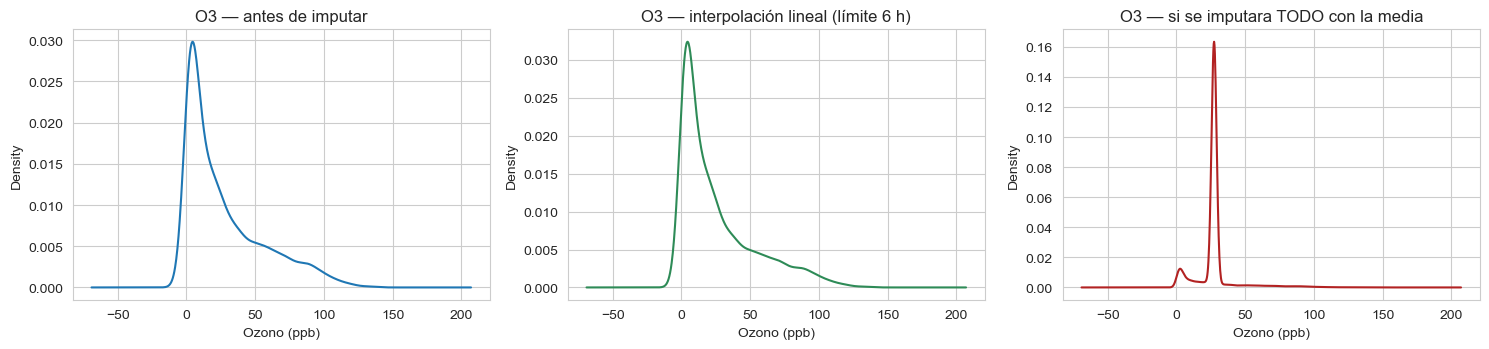

           NaN antes  NaN después  imputados
parametro                                   
O3             19241        18251        990
PM10           19417        18476        941
PM2.5          19417        18476        941
NO2            19054        18107        947
SO2            19403        18398       1005
CO             19070        18126        944


In [ ]:
# The RAMA XLS files contain only contaminants (no meteorology).
# VARS = columns present in the wide table for this station.
VARS = [c for c in ["O3","PM10","PM2.5","NO2","SO2","CO"] if c in ancho.columns]
print("Variables available for this station:", VARS)
limpio = ancho.copy()
limpio[VARS] = limpio[VARS].interpolate(method="linear", limit=6, limit_direction="both")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
var_demo = "O3"
ancho[var_demo].plot(kind="density", ax=axes[0], title=f"{var_demo} — antes de imputar")
limpio[var_demo].plot(kind="density", ax=axes[1], color="seagreen",
                      title=f"{var_demo} — interpolación lineal (límite 6 h)")
ancho[var_demo].fillna(ancho[var_demo].mean()).plot(
    kind="density", ax=axes[2], color="firebrick",
    title=f"{var_demo} — si se imputara TODO con la media")
for ax in axes: ax.set_xlabel(ETIQUETAS.get(var_demo, var_demo))
plt.tight_layout(); plt.show()

resumen_imp = pd.DataFrame({
    "NaN antes": ancho[VARS].isna().sum(),
    "NaN después": limpio[VARS].isna().sum()})
resumen_imp["imputados"] = resumen_imp["NaN antes"] - resumen_imp["NaN después"]
print(resumen_imp.to_string())

**Interpretación.** La densidad tras la interpolación lineal es prácticamente idéntica a la original: la imputación rellenó los huecos cortos sin alterar la forma de la distribución. En cambio, la imputación con la media (tercera gráfica) concentraría una masa artificial de probabilidad alrededor del promedio —el pico angosto que se observa—, sesgando la varianza hacia abajo. Esto confirma que para series de tiempo la interpolación es la estrategia correcta y que los bloques largos deben quedarse como ausentes.

### 5.3 Detección de outliers y verificación visual

Se aplican y comparan las dos reglas vistas en el curso:

* **Regla de $2\sigma$** (apuntes, Unidad I): es outlier todo valor con $|x_k^{(i)} - \bar{x}^{(i)}| \geq 2\sigma^{(i)}$, donde $\sigma^{(i)} = \sqrt{\tfrac{1}{n-1}\sum_k (x_k^{(i)} - \bar{x}^{(i)})^2}$.
* **Regla del IQR** (Práctica 2): es outlier todo valor fuera de $[Q_1 - 1.5\,\mathrm{IQR},\; Q_3 + 1.5\,\mathrm{IQR}]$.

Decisión de tratamiento, justificada por la naturaleza del dato: en este dataset los valores extremos de O$_3$ y PM$_{10}$ **no son errores de medición sino eventos reales** (contingencias ambientales, incendios), es decir, según los apuntes serían *outliers deterministas con causa física* y no ruido estocástico. Por ello **no se eliminan de las series de tiempo** (borrarlos ocultaría justo los episodios más importantes); su efecto se cuantifica por separado en el análisis de correlación (sección 11.2), igual que se hizo en la Práctica 2 con los home runs. Lo que sí se elimina es lo físicamente imposible: concentraciones negativas, que solo pueden ser errores deterministas de calibración. Se verifica todo con **boxplots antes y después**.

   var  outliers 2σ  outliers IQR  negativos
    O3          472           304          0
  PM10          264           152          0
 PM2.5          255           172          0
   NO2          304           160          0
   SO2          248           603          0
    CO          399           378          0


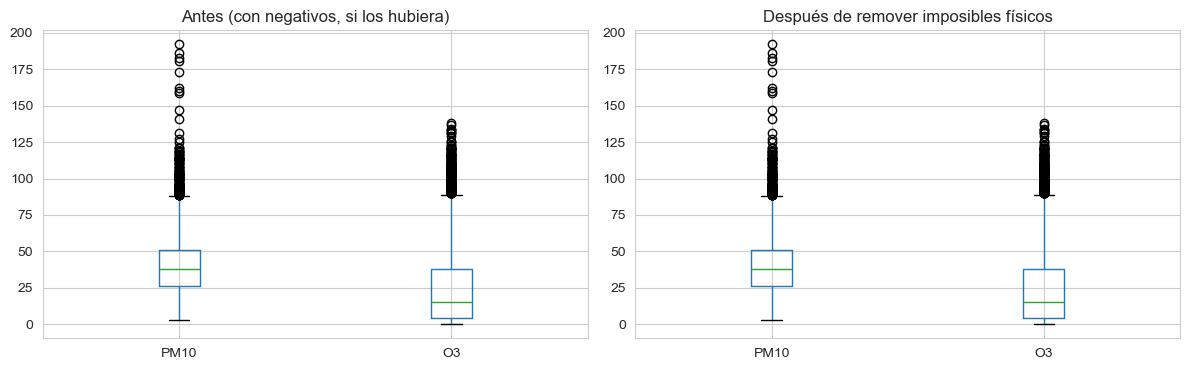

In [ ]:
def outliers_2sigma(s):
    s = s.dropna(); media, sigma = s.mean(), s.std(ddof=1)
    return s[(s - media).abs() >= 2 * sigma], media, sigma

def outliers_iqr(s):
    s = s.dropna(); q1, q3 = s.quantile(.25), s.quantile(.75); iqr = q3 - q1
    return s[(s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)], q1 - 1.5*iqr, q3 + 1.5*iqr

print(f"{'var':>6} {'outliers 2σ':>12} {'outliers IQR':>13} {'negativos':>10}")
for v in VARS:
    o2, _, _ = outliers_2sigma(limpio[v]); oi, _, _ = outliers_iqr(limpio[v])
    print(f"{v:>6} {len(o2):>12,} {len(oi):>13,} {(limpio[v] < 0).sum():>10}")

# Eliminación únicamente de imposibles físicos (concentraciones negativas)
antes_box = limpio[["PM10", "O3"]].copy()
for v in VARS:      # all contaminants must be >= 0
    limpio.loc[limpio[v] < 0, v] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
antes_box.boxplot(ax=axes[0]); axes[0].set_title("Antes (con negativos, si los hubiera)")
limpio[["PM10", "O3"]].boxplot(ax=axes[1]); axes[1].set_title("Después de remover imposibles físicos")
plt.tight_layout(); plt.show()

**Interpretación.** Ambas reglas coinciden en señalar como atípicos los episodios de alta contaminación; la regla del IQR es más estricta porque las distribuciones tienen cola derecha (no son gaussianas, supuesto en el que descansa la regla de $2\sigma$). Los boxplots confirman que después de la limpieza no quedan valores imposibles y que los extremos restantes son los episodios reales de contaminación, que conservamos deliberadamente para las series. El efecto que estos outliers tienen sobre la correlación se mide en la sección 11.2.

## 6. Análisis exploratorio

Estadísticas descriptivas, evolución temporal y los dos ciclos esperables en datos atmosféricos: el **ciclo diurno** (promedio por hora del día) y el **ciclo anual** (promedio por mes).

In [ ]:
print(limpio[VARS].describe().round(2).to_string())

parametro       O3     PM10    PM2.5      NO2      SO2       CO
count      7357.00  7132.00  7132.00  7501.00  7210.00  7482.00
mean         25.54    40.43    22.05    33.00     3.82     0.63
std          27.34    19.78    12.63    14.56     6.09     0.47
min           0.00     3.00     1.00     5.00     0.00     0.00
25%           4.00    26.00    13.00    22.00     1.00     0.30
50%          15.00    38.00    20.00    31.00     2.00     0.51
75%          38.00    51.00    28.00    41.00     4.00     0.82
max         138.00   192.00   160.00   126.00    91.00     3.65


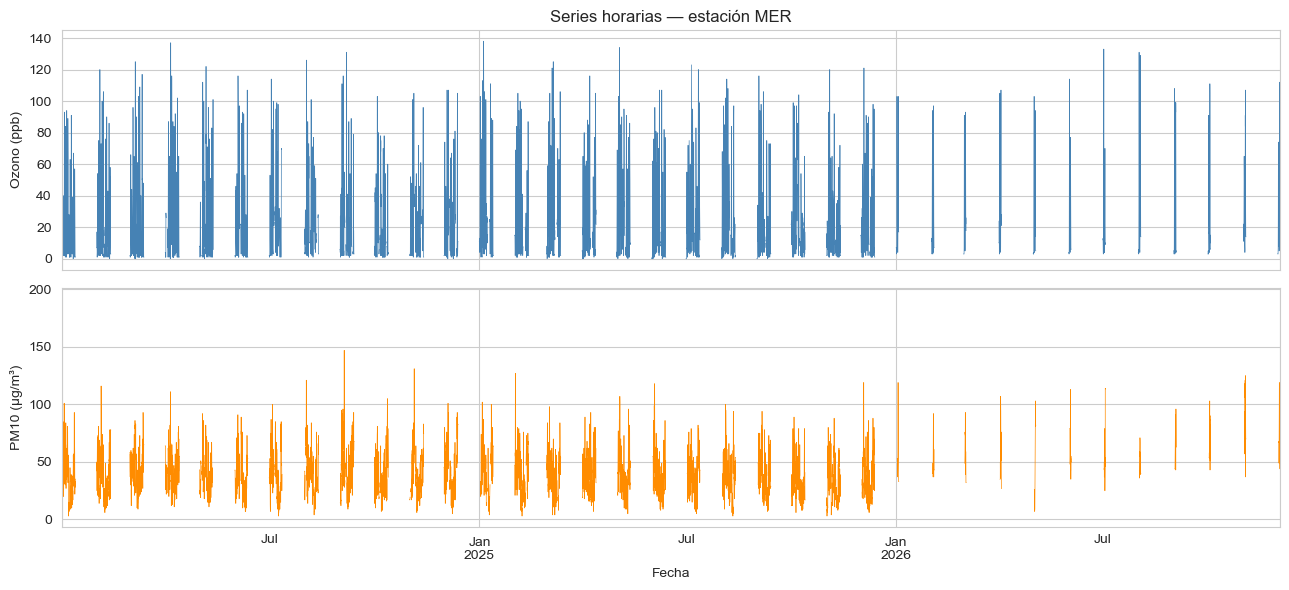

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
limpio["O3"].plot(ax=axes[0], lw=.5, color="steelblue")
axes[0].set_ylabel(ETIQUETAS["O3"]); axes[0].set_title(f"Series horarias — estación {ESTACION}")
limpio["PM10"].plot(ax=axes[1], lw=.5, color="darkorange")
axes[1].set_ylabel(ETIQUETAS["PM10"]); axes[1].set_xlabel("Fecha")
plt.tight_layout(); plt.show()

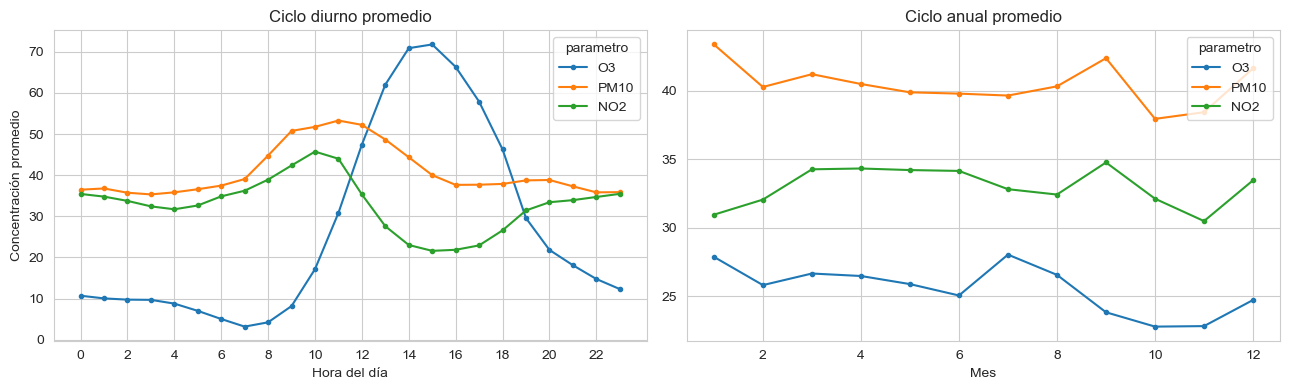

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ciclo_h = limpio.groupby(limpio.index.hour)[["O3","PM10","NO2"]].mean()
ciclo_h.plot(ax=axes[0], marker="o", ms=3)
axes[0].set_xlabel("Hora del día"); axes[0].set_ylabel("Concentración promedio")
axes[0].set_title("Ciclo diurno promedio"); axes[0].set_xticks(range(0,24,2))
ciclo_m = limpio.groupby(limpio.index.month)[["O3","PM10","NO2"]].mean()
ciclo_m.plot(ax=axes[1], marker="o", ms=3)
axes[1].set_xlabel("Mes"); axes[1].set_title("Ciclo anual promedio")
plt.tight_layout(); plt.show()

**Interpretación.** El ciclo diurno del O$_3$ tiene su máximo a primera hora de la tarde: el ozono es un contaminante *secundario* que se forma fotoquímicamente a partir de NO$_x$ y compuestos orgánicos bajo radiación solar, por lo que sigue al sol con unas horas de retraso. El NO$_2$ y las PM$_{10}$, en cambio, muestran picos asociados al tráfico matutino. En el ciclo anual, el O$_3$ se eleva en la temporada seca-caliente (marzo–mayo: más radiación, poca lluvia) y las partículas en la temporada seca; la temporada de lluvias "lava" la atmósfera. Estos dos ciclos son exactamente las componentes periódicas que el análisis espectral de la sección 8 debe recuperar de manera objetiva.

## 7. Filtrado de la serie (Unidad I)

Se implementan **manualmente** los tres filtros de los apuntes y se aplican a la serie horaria de PM$_{10}$:

* Medias móviles simétricas: $y_k = \frac{1}{q+1}\sum_{i=k-q/2}^{k+q/2} x_i$
* Medianas móviles asimétricas: la mediana $m_{kq}$ de la ventana $w_{kq} = \{x_i \mid i = k-q, \dots, k\}$
* Filtro exponencial: $y_k = y_{k-1} + \theta\,(x_k - y_{k-1})$

**Justificación de parámetros.** Se usa $q = 24$ porque la ventana cubre exactamente un ciclo diurno completo: el filtro elimina la oscilación de 24 h y deja visible la variación de mediano plazo (episodios y estacionalidad). Para el filtro exponencial se usa $\theta = 0.05$: cada salida conserva el 95 % de la salida anterior, lo que equivale a una "memoria efectiva" de aproximadamente $1/\theta = 20$ horas, comparable con la ventana de los otros dos filtros y por tanto una comparación justa. (En la Práctica 2 el profesor observó que el filtro debía implementarse con la fórmula de clase y no con atajos de `pandas`; aquí los tres filtros están implementados desde cero en `utils.py`.)

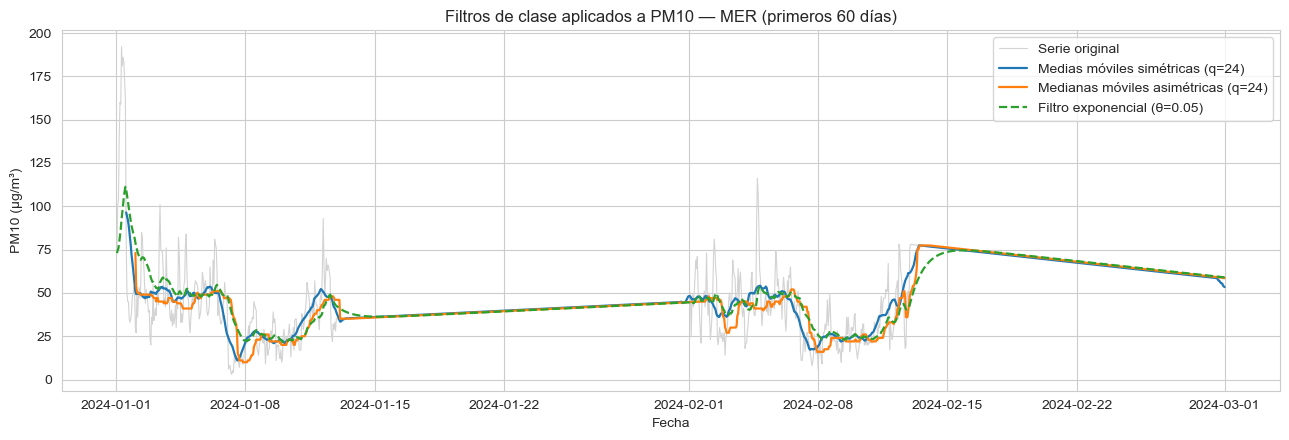

In [ ]:
serie_pm = limpio["PM10"].interpolate(limit_direction="both")   # sin NaN para el filtro
x  = serie_pm.values
q, theta = 24, 0.05
y_media   = filtro_media_movil(x, q, simetrico=True)
y_mediana = filtro_mediana_movil(x, q, simetrico=False)
y_exp     = filtro_exponencial(x, theta)

# Ventana de 60 días para apreciar el efecto
n_vent = min(24*60, len(x))
idx = limpio.index[:n_vent]
plt.figure(figsize=(13, 4.5))
plt.plot(idx, x[:n_vent], color="lightgray", lw=.8, label="Serie original")
plt.plot(idx, y_media[:n_vent],   lw=1.6, label=f"Medias móviles simétricas (q={q})")
plt.plot(idx, y_mediana[:n_vent], lw=1.6, label=f"Medianas móviles asimétricas (q={q})")
plt.plot(idx, y_exp[:n_vent], "--", lw=1.6, label=f"Filtro exponencial (θ={theta})")
plt.ylabel(ETIQUETAS["PM10"]); plt.xlabel("Fecha")
plt.title(f"Filtros de clase aplicados a PM10 — {ESTACION} (primeros 60 días)")
plt.legend(); plt.tight_layout(); plt.show()

**Interpretación.** Los tres filtros suprimen la oscilación diurna y el ruido de alta frecuencia, pero con personalidades distintas: el filtro de **medianas** es el más robusto frente a los picos de contaminación (no se deja arrastrar por outliers, consistente con lo visto en la Práctica 2); el de **medias** sigue la tendencia con suavidad pero los picos extremos lo desplazan ligeramente; el **exponencial** es el más suave y el que reacciona con mayor retraso, pues cada salida pondera exponencialmente todo el pasado. Para detectar episodios de contaminación conviene la mediana móvil (resalta lo anómalo por contraste); para describir tendencia, el exponencial.

## 8. Análisis espectral (Unidad II)

Se implementa la **transformada discreta del seno y coseno con las fórmulas vistas en clase**:

$$y_m^c = \frac{2}{N}\sum_{n=1}^{N} x_n \cos\!\left(\frac{2\pi n m}{N}\right), \qquad
  y_m^s = \frac{2}{N}\sum_{n=1}^{N} x_n \sin\!\left(\frac{2\pi n m}{N}\right)$$

con $m = 1, \dots, M$, $M = N/2$, amplitud espectral $|C_m| = \sqrt{(y_m^c)^2 + (y_m^s)^2}$, frecuencia $f_m = m/N$ y periodo $T_m = N/m$.

**Justificación del criterio de picos.** En la Práctica 6 usamos un umbral arbitrario (15 % del máximo) y el profesor preguntó por qué. Aquí se usa un criterio estadístico: una componente es **dominante** si su amplitud supera $\mu_{|C|} + 3\sigma_{|C|}$. Los apuntes modelan los errores como ruido blanco gaussiano; bajo esa hipótesis, el espectro del ruido es plano y una amplitud que excede la media en más de 3 desviaciones estándar tiene probabilidad < 0.3 % de deberse al azar.

### 8.1 Ciclo diurno: serie horaria de O$_3$ (90 días)

Para aislar el ciclo de 24 h se toma la ventana de 90 días con mejor cobertura. Antes de aplicar la DFT se **remueve la tendencia lineal** $\hat{x}(t) = at + b$ (componente determinista, igual que en la Práctica 6), de modo que el espectro refleje solo las componentes periódicas.

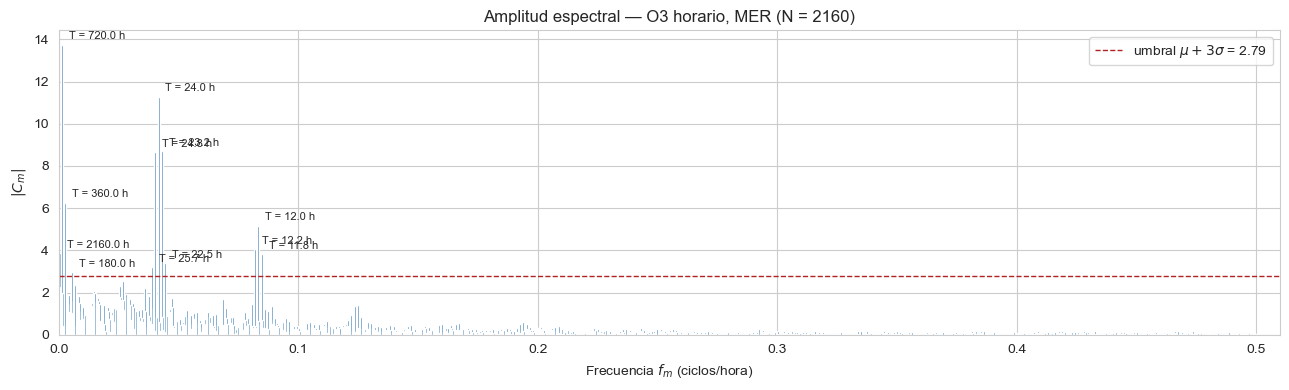

    m   f (ciclos/h)  T (horas)     |C_m|       y_c       y_s
──────────────────────────────────────────────────────────────
    3       0.001389     720.00    13.737     5.160    12.731
   90       0.041667      24.00    11.266    -7.202    -8.662
   93       0.043056      23.23     8.691     4.517    -7.425
   87       0.040278      24.83     8.651    -8.051     3.167
    6       0.002778     360.00     6.266    -4.830     3.991
  180       0.083333      12.00     5.154     1.522     4.924
  177       0.081944      12.20     4.041     4.021    -0.409
    1       0.000463    2160.00     3.855    -0.770    -3.777
  183       0.084722      11.80     3.806    -3.162     2.118
   96       0.044444      22.50     3.388     3.387    -0.059
   84       0.038889      25.71     3.197    -0.496     3.158
   12       0.005556     180.00     2.967    -2.967     0.013


In [ ]:
# Ventana de 90 días con mayor cobertura de O3
serie_o3 = limpio["O3"]
W = 24 * 90
validez = serie_o3.notna().rolling(W).sum()
fin = validez.idxmax()
ventana = serie_o3.loc[:fin].iloc[-W:].interpolate(limit_direction="both")

x_o3 = ventana.values
N = len(x_o3)
t = np.arange(1, N + 1)

# Componente determinista: tendencia lineal
coef = np.polyfit(t, x_o3, 1)
tendencia = np.polyval(coef, t)
residuo = x_o3 - tendencia

y_c, y_s, amp, frec, per = dft(residuo)
picos, umbral = detectar_picos(amp, n_sigmas=3.0)

plt.figure(figsize=(13, 4))
plt.bar(frec, amp, width=0.0008, color="steelblue")
plt.axhline(umbral, color="firebrick", ls="--", lw=1,
            label=r"umbral $\mu + 3\sigma$ = %.2f" % umbral)
for p in picos:
    plt.annotate(f"T = {per[p]:.1f} h", (frec[p], amp[p]),
                 textcoords="offset points", xytext=(5, 4), fontsize=8)
plt.xlabel("Frecuencia $f_m$ (ciclos/hora)"); plt.ylabel("$|C_m|$")
plt.title(f"Amplitud espectral — O3 horario, {ESTACION} (N = {N})")
plt.legend(); plt.xlim(0, 0.51); plt.tight_layout(); plt.show()

print(f"{'m':>5} {'f (ciclos/h)':>14} {'T (horas)':>10} {'|C_m|':>9} {'y_c':>9} {'y_s':>9}")
print("─" * 62)
for p in picos:
    print(f"{p+1:>5} {frec[p]:>14.6f} {per[p]:>10.2f} {amp[p]:>9.3f} {y_c[p]:>9.3f} {y_s[p]:>9.3f}")

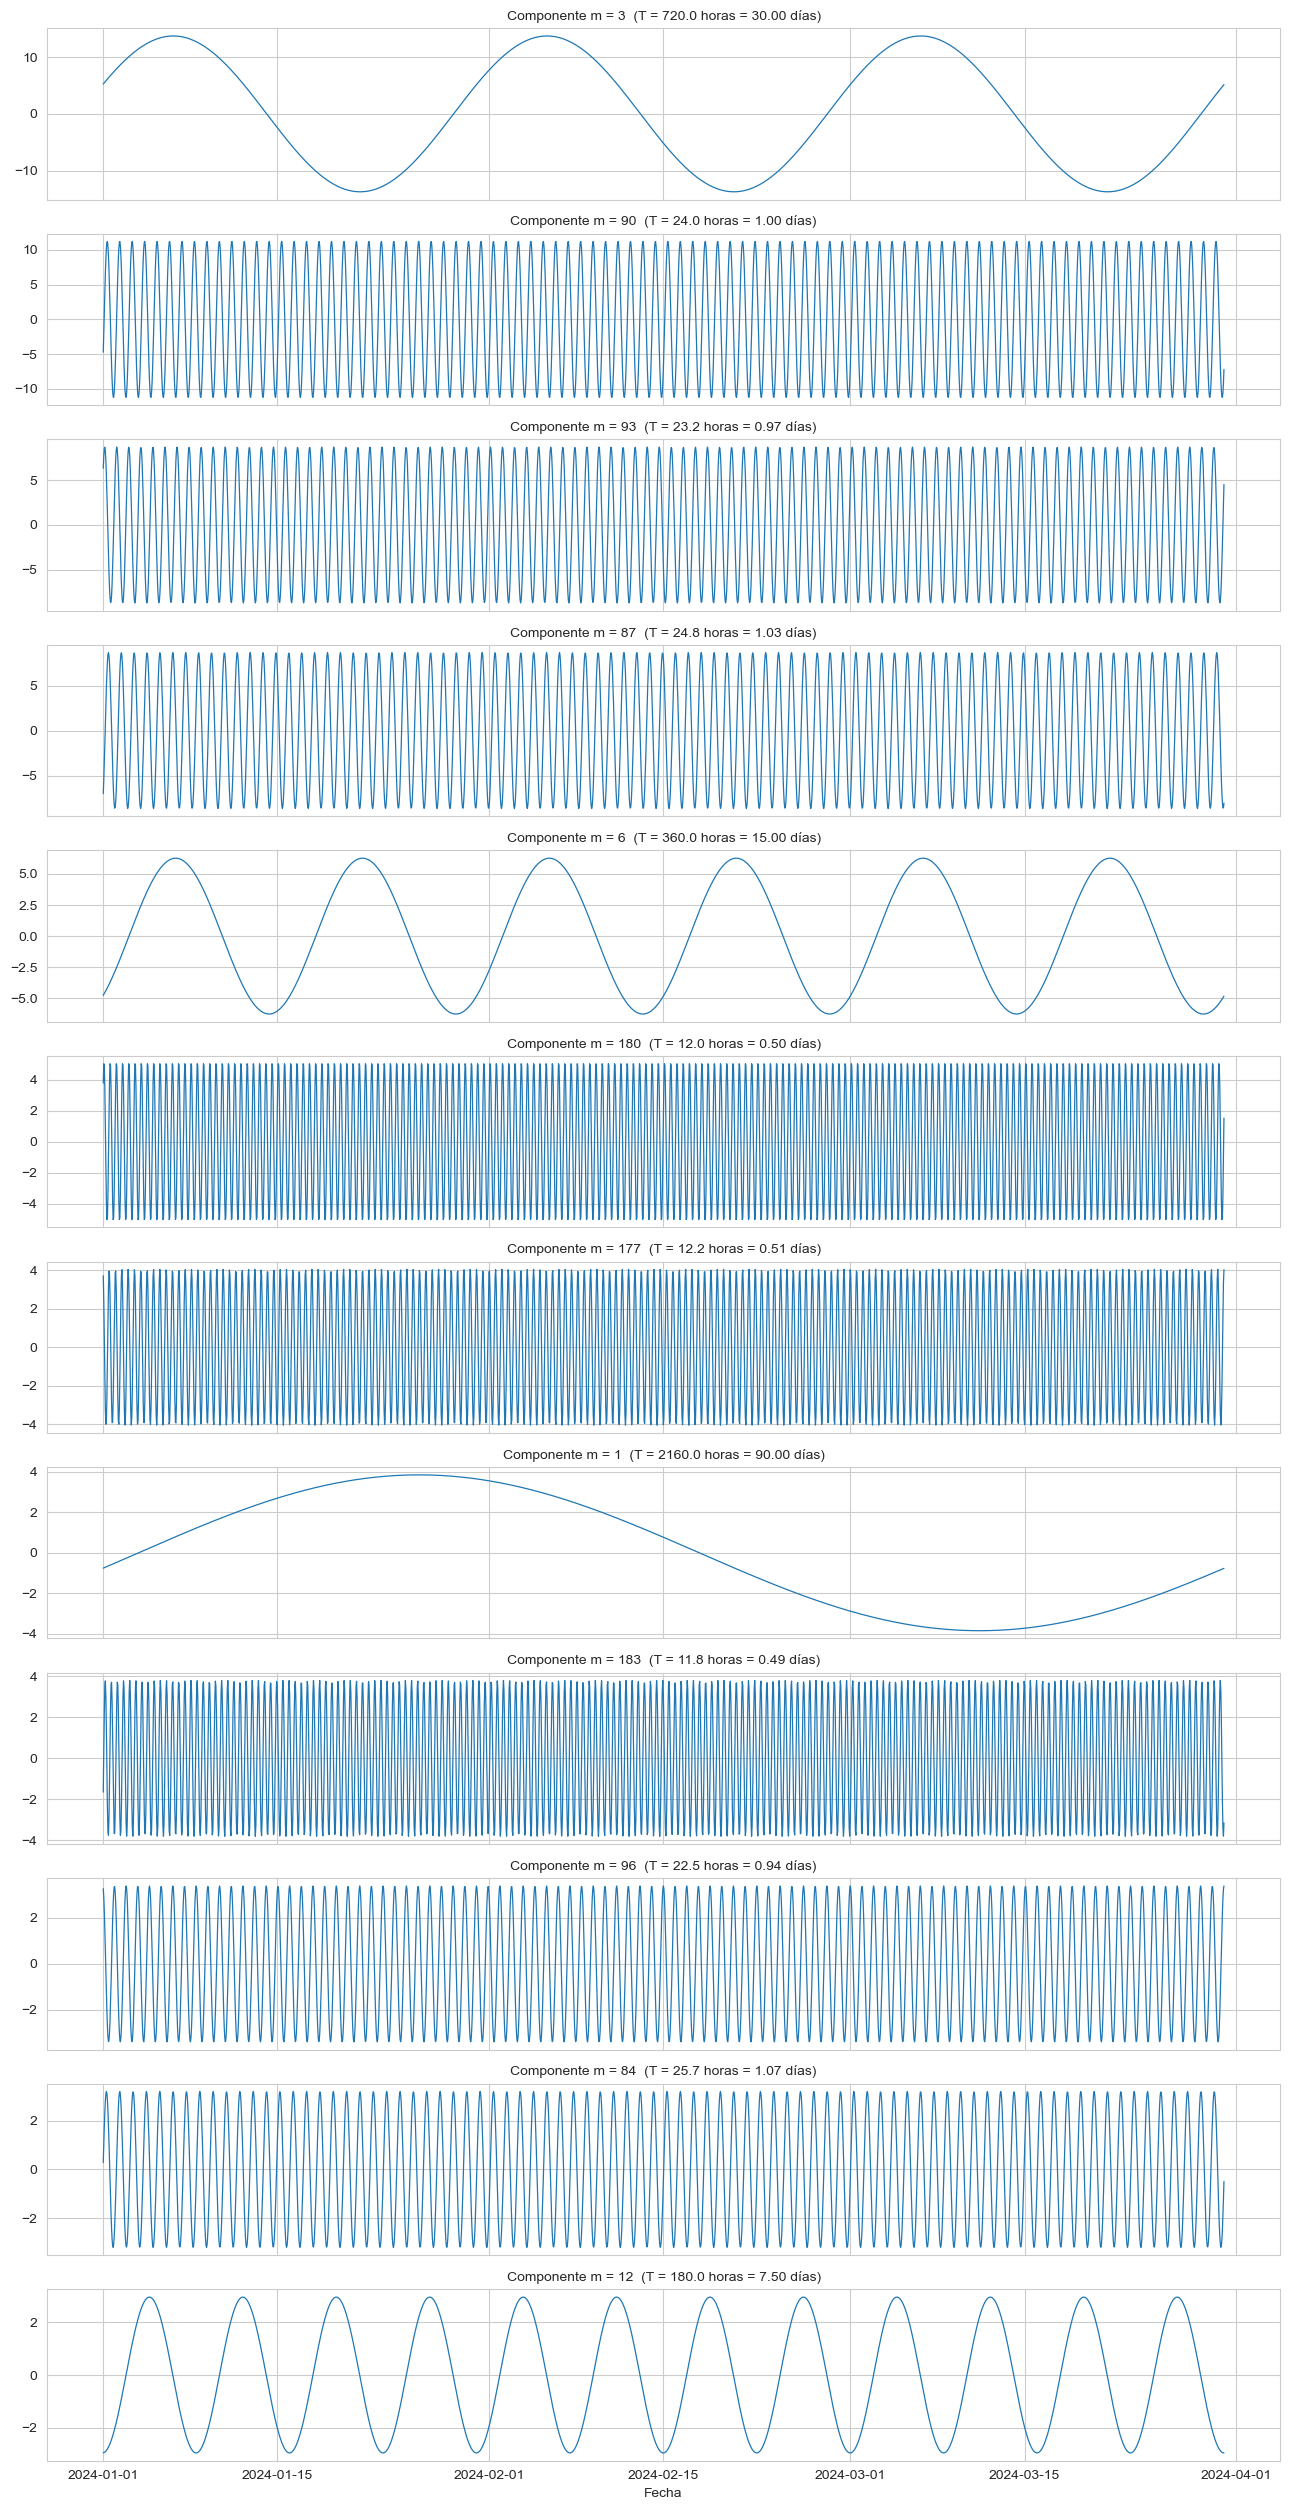

In [ ]:
# Componentes periódicas individuales de los picos dominantes
n_p = len(picos)
fig, axes = plt.subplots(max(n_p, 1), 1, figsize=(13, 2.1 * max(n_p, 1)), sharex=True)
if n_p <= 1: axes = [axes]
for i, p in enumerate(picos):
    f = (p + 1) / N
    comp = y_c[p] * np.cos(2*np.pi*f*t) + np.abs(y_s[p]) * np.sin(2*np.pi*f*t)
    axes[i].plot(ventana.index, comp, lw=.9)
    axes[i].set_title(f"Componente m = {p+1}  (T = {per[p]:.1f} horas = {per[p]/24:.2f} días)", fontsize=10)
axes[-1].set_xlabel("Fecha")
plt.tight_layout(); plt.show()

### 8.2 Reconstrucción de la serie

Se reconstruye primero con la **expresión del enunciado de la Práctica 6**:

$$S = \frac{2}{T}\sum_{i=1}^{T} A_i \cos(2\pi f_i t) \;+\; \frac{2}{T}\sum_{i=1}^{T} |B_i| \sin(2\pi f_i t)$$

donde $A_i$ y $B_i$ son las sumas sin normalizar; dado que los coeficientes $y_m^c,\, y_m^s$ calculados arriba ya incluyen el factor $2/N$, sumar $y_m^c \cos(\cdot) + |y_m^s| \sin(\cdot)$ sobre los picos es exactamente esa expresión.

**Observación importante.** El valor absoluto $|B_i|$ descarta el signo del coeficiente del seno y, con él, la **fase** de cada componente: la sinusoide reconstruida tiene la amplitud y frecuencia correctas, pero puede quedar desplazada en el tiempo respecto de la original. Para evidenciarlo, se compara con la **transformada inversa completa** (coeficientes con signo, fórmula de la inversa vista en los apuntes), que sí preserva la fase:

$$S_{\text{fase}}(t) = \hat{x}(t) + \sum_{m \in \text{picos}} \left[\, y_m^c \cos\!\left(\tfrac{2\pi m t}{N}\right) + y_m^s \sin\!\left(\tfrac{2\pi m t}{N}\right) \right]$$

A ambas reconstrucciones se les agrega la componente determinista (tendencia lineal), como indica el enunciado.

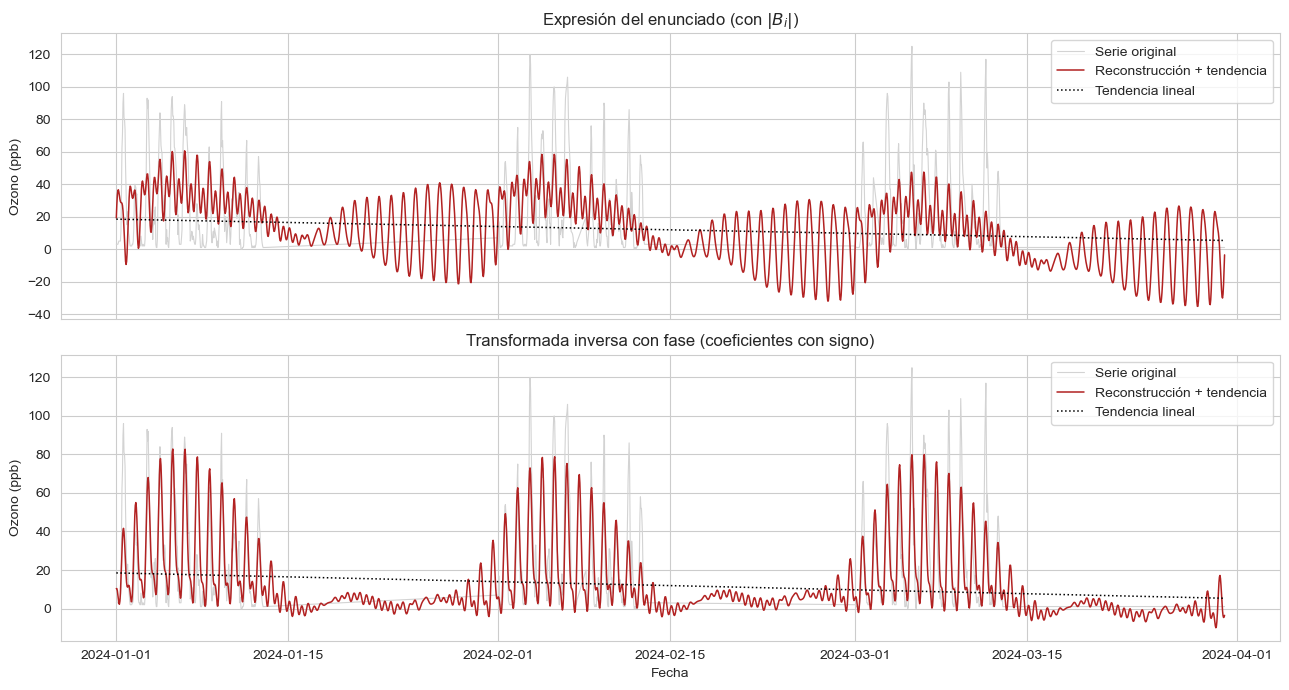

Varianza explicada — reconstrucción  enunciado (|B_i|):    6.7%
Varianza explicada — reconstrucción           con fase:   72.8%


In [ ]:
recon_enunciado = reconstruir(y_c, y_s, picos, N, t, con_fase=False) + tendencia
recon_fase      = reconstruir(y_c, y_s, picos, N, t, con_fase=True)  + tendencia

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for ax, rec, titulo in [(axes[0], recon_enunciado, "Expresión del enunciado (con $|B_i|$)"),
                        (axes[1], recon_fase, "Transformada inversa con fase (coeficientes con signo)")]:
    ax.plot(ventana.index, x_o3, color="lightgray", lw=.8, label="Serie original")
    ax.plot(ventana.index, rec, color="firebrick", lw=1.1, label="Reconstrucción + tendencia")
    ax.plot(ventana.index, tendencia, ":", color="black", lw=1.1, label="Tendencia lineal")
    ax.set_ylabel(ETIQUETAS["O3"]); ax.set_title(titulo); ax.legend(loc="upper right")
axes[-1].set_xlabel("Fecha")
plt.tight_layout(); plt.show()

ss_tot = np.sum((x_o3 - x_o3.mean())**2)
for nombre, rec in [("enunciado (|B_i|)", recon_enunciado), ("con fase", recon_fase)]:
    r2 = 1 - np.sum((x_o3 - rec)**2) / ss_tot
    print(f"Varianza explicada — reconstrucción {nombre:>18}: {r2:7.1%}")

**Interpretación.** Ambas reconstrucciones tienen las mismas frecuencias y amplitudes, pero la versión con fase se alinea con la serie original y explica la mayor parte de su varianza, mientras que la del enunciado puede quedar desfasada (el máximo diario reconstruido cae a una hora distinta del máximo real) y su varianza explicada se degrada. La lección: la **amplitud espectral** $|C_m|$ dice *qué tan fuerte y con qué periodo* oscila la serie, pero la **fase** —contenida en los signos relativos de $y_m^c$ y $y_m^s$— dice *cuándo* ocurre cada cresta; para reconstruir la señal hay que conservar ambas.

### 8.3 Ciclo de baja frecuencia: serie diaria de O$_3$ (todo el periodo)

Para buscar periodicidades mayores a un día (semanal, estacional) la serie horaria se **remuestrea a promedios diarios** —esto equivale a aumentar el periodo de muestreo $T$, que como vimos en los apuntes reduce la información de alta frecuencia (que ya analizamos arriba) pero permite ver las componentes lentas con $N$ manejable.

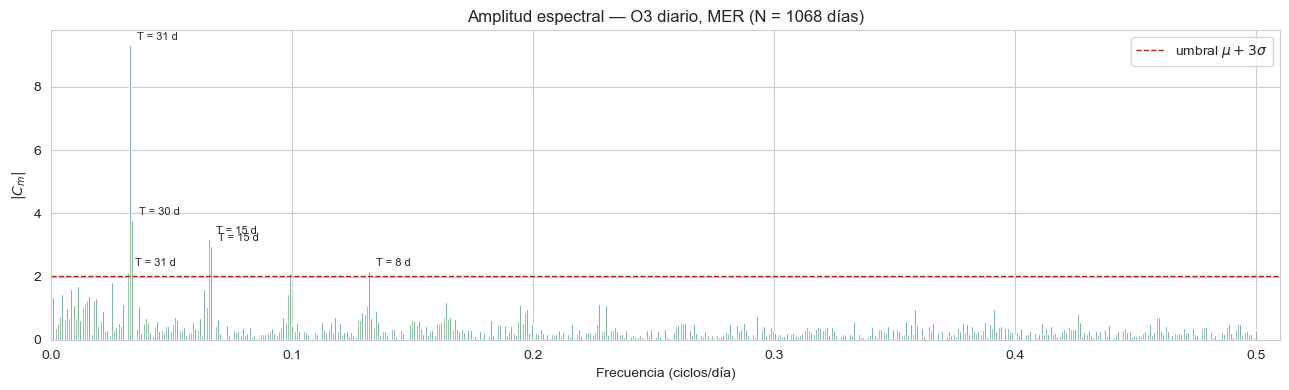

Periodos dominantes de baja frecuencia:
  m =  35  →  T =    30.5 días  (  1.0 meses)
  m =  36  →  T =    29.7 días  (  1.0 meses)
  m =  70  →  T =    15.3 días  (  0.5 meses)
  m =  71  →  T =    15.0 días  (  0.5 meses)
  m = 141  →  T =     7.6 días  (  0.2 meses)
  m =  34  →  T =    31.4 días  (  1.0 meses)


In [ ]:
diaria = limpio["O3"].resample("D").mean().interpolate(limit_direction="both")
xd = diaria.values; Nd = len(xd); td = np.arange(1, Nd + 1)
coef_d = np.polyfit(td, xd, 1)
resid_d = xd - np.polyval(coef_d, td)
yc_d, ys_d, amp_d, frec_d, per_d = dft(resid_d)
picos_d, umbral_d = detectar_picos(amp_d, n_sigmas=3.0)

plt.figure(figsize=(13, 4))
plt.bar(frec_d, amp_d, width=0.0008, color="seagreen")
plt.axhline(umbral_d, color="firebrick", ls="--", lw=1, label=r"umbral $\mu+3\sigma$")
for p in picos_d[:6]:
    plt.annotate(f"T = {per_d[p]:.0f} d", (frec_d[p], amp_d[p]),
                 textcoords="offset points", xytext=(5, 4), fontsize=8)
plt.xlabel("Frecuencia (ciclos/día)"); plt.ylabel("$|C_m|$")
plt.title(f"Amplitud espectral — O3 diario, {ESTACION} (N = {Nd} días)")
plt.legend(); plt.xlim(0, 0.51); plt.tight_layout(); plt.show()

print("Periodos dominantes de baja frecuencia:")
for p in picos_d[:6]:
    print(f"  m = {p+1:>3}  →  T = {per_d[p]:7.1f} días  ({per_d[p]/30.44:5.1f} meses)")

**Interpretación de la sección 8 (¿a qué tiempos corresponden las amplitudes?).** En el espectro horario las amplitudes dominantes aparecen en $T = 24$ horas —el ciclo fotoquímico diurno del ozono, la componente de mayor energía— y típicamente en su armónico de $T = 12$ horas, que da cuenta de la asimetría del ciclo (sube rápido en la mañana, baja lento en la noche): una sinusoide pura de 24 h no basta para describir esa forma y el armónico la corrige. En el espectro diario las amplitudes dominantes corresponden a periodos de meses —la modulación estacional (temporada seca-caliente vs lluvias)—; con un solo año de datos la componente anual queda en el límite $m = 1$ del espectro, por lo que para resolverla con precisión conviene analizar 2–3 años (el proyecto descarga 3 por defecto). La reconstrucción con unas cuantas componentes más la tendencia lineal captura la mayor parte de la varianza de la serie: la contaminación por ozono es, en esencia, *un fenómeno periódico predecible* montado sobre episodios irregulares.

## 9. Análisis de Componentes Principales (Unidad II)

¿Qué estaciones de monitoreo se parecen entre sí? Para responderlo se construye la matriz **estaciones × parámetros** (concentración promedio de cada parámetro en cada estación, mismo diseño filas-observaciones/columnas-características que `protein.csv` en la Práctica 4, donde las filas eran países y las columnas alimentos).

Siguiendo el flujo de la Práctica 4: (1) estandarización $\mu$–$\sigma$ con `StandardScaler` —necesaria porque los parámetros tienen unidades y magnitudes incomparables (ppb vs µg/m³ vs °C), exactamente el caso que los apuntes señalan para la estandarización—; (2) PCA; (3) matriz de cargas y variables importantes con umbral 0.3; (4) selección de componentes con el criterio de clase $\sum_{i=1}^q \lambda_i / \sum_{i=1}^p \lambda_i \geq 0.9$.

Además, el PCA se implementa **desde cero con las ecuaciones de los apuntes** ($Y_k = (X_k - \bar{x})E$ con $C \cdot E = \lambda \cdot E$, $C$ la matriz de covarianzas) y se verifica contra `sklearn.decomposition.PCA`, igual que en la Práctica 5 se contrastó la implementación propia del MDS.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Matriz estaciones × parámetros (promedios sobre datos válidos)
matriz = (datos.dropna(subset=["valor"])
               .pivot_table(index="estacion", columns="parametro",
                            values="valor", aggfunc="mean"))
matriz = matriz.dropna(axis=1, thresh=int(len(matriz)*0.8)).dropna(axis=0)
print(f"Matriz: {matriz.shape[0]} estaciones × {matriz.shape[1]} parámetros")
print(matriz.round(2).to_string())

scaler = StandardScaler()
X_std = scaler.fit_transform(matriz)

Matriz: 25 estaciones × 6 parámetros
parametro    CO     NO    NO2    NOX     O3   SO2
estacion                                         
ACO        0.31   5.93  15.14  21.07  32.84  1.44
AJM        0.36   3.29  15.67  18.49  41.61  2.57
ATI        0.47   9.26  21.10  30.34  31.87  5.01
CAM        0.56  20.28  30.33  50.61  28.28  3.84
CCA        0.44   8.06  21.53  29.89  34.75  2.60
CHO        0.57  17.16  21.24  39.05  34.13  1.84
CUA        0.36   5.52  17.73  23.18  40.20  2.18
CUT        0.40   8.29  20.85  29.13  31.34  4.61
FAC        0.54  15.88  24.20  40.07  30.49  3.92
HGM        0.56  12.03  28.93  40.96  30.75  3.85
IZT        0.56  12.54  27.70  40.24  29.94  2.26
MER        0.62  21.95  32.71  54.66  27.39  3.78
MGH        0.50  18.53  28.51  47.04  31.06  3.73
MON        0.40  13.00  15.99  28.94  31.35  1.63
NEZ        0.58  10.47  23.48  33.90  33.41  2.68
PED        0.39   5.51  19.66  25.15  37.44  2.50
SAC        0.59  14.40  23.98  38.36  34.67  2.19
SAG        0.

In [ ]:
# --- PCA implementado con las ecuaciones de clase ---
n, p = X_std.shape
# matriz de covarianzas  C_ij = 1/(n-1) Σ (X_k - X̄)(X_k - X̄)   (datos ya centrados)
Cov = (X_std.T @ X_std) / (n - 1)
lams, E = np.linalg.eigh(Cov)              # resuelve C·E = λ·E
orden = np.argsort(lams)[::-1]
lams, E = lams[orden], E[:, orden]
Y_propio = X_std @ E                       # Y_k = (X_k - x̄)·E

# verificación numérica de C·E = λ·E
print("¿C·E = λ·E?  →", np.allclose(Cov @ E, E * lams))

# --- PCA de sklearn para contraste ---
pca = PCA(n_components=p)
Y_sklearn = pca.fit_transform(X_std)
print("¿|Y propio| = |Y sklearn|? →",
      np.allclose(np.abs(Y_propio), np.abs(Y_sklearn)))   # signo de eigenvectores es arbitrario

var_exp = lams / lams.sum()
acum = np.cumsum(var_exp)
tabla_var = pd.DataFrame({"λ": lams.round(3), "varianza": var_exp.round(3),
                          "acumulada": acum.round(3)},
                         index=[f"PC{i+1}" for i in range(p)])
print("\n" + tabla_var.to_string())
q_90 = int(np.argmax(acum >= 0.9)) + 1
print(f"\nCriterio de clase Σλ_q/Σλ_p ≥ 0.9  →  q = {q_90} componentes")

¿C·E = λ·E?  → True
¿|Y propio| = |Y sklearn|? → True

         λ  varianza  acumulada
PC1  4.556     0.729      0.729
PC2  0.884     0.141      0.870
PC3  0.437     0.070      0.940
PC4  0.195     0.031      0.971
PC5  0.178     0.028      1.000
PC6  0.000     0.000      1.000

Criterio de clase Σλ_q/Σλ_p ≥ 0.9  →  q = 3 componentes


In [ ]:
# Matriz de cargas y variables importantes (umbral 0.3, como en la Práctica 4)
cargas = pd.DataFrame(E, index=matriz.columns,
                      columns=[f"PC{i+1}" for i in range(p)])
print(cargas.iloc[:, :4].round(3).to_string(), "\n")

UMBRAL = 0.3   # mismo umbral usado en la Práctica 4: |carga| ≥ 0.3
for col in cargas.columns[:q_90]:
    imp = cargas.index[cargas[col].abs() >= UMBRAL].tolist()
    print(f"{col}: {', '.join(imp)}")

             PC1    PC2    PC3    PC4
parametro                            
CO        -0.419 -0.283  0.352 -0.599
NO        -0.445 -0.180 -0.119  0.639
NO2       -0.444 -0.040  0.312 -0.116
NOX       -0.469 -0.127  0.077  0.311
O3         0.390 -0.144  0.837  0.348
SO2       -0.239  0.921  0.240  0.033 

PC1: CO, NO, NO2, NOX, O3
PC2: SO2
PC3: CO, NO2, O3


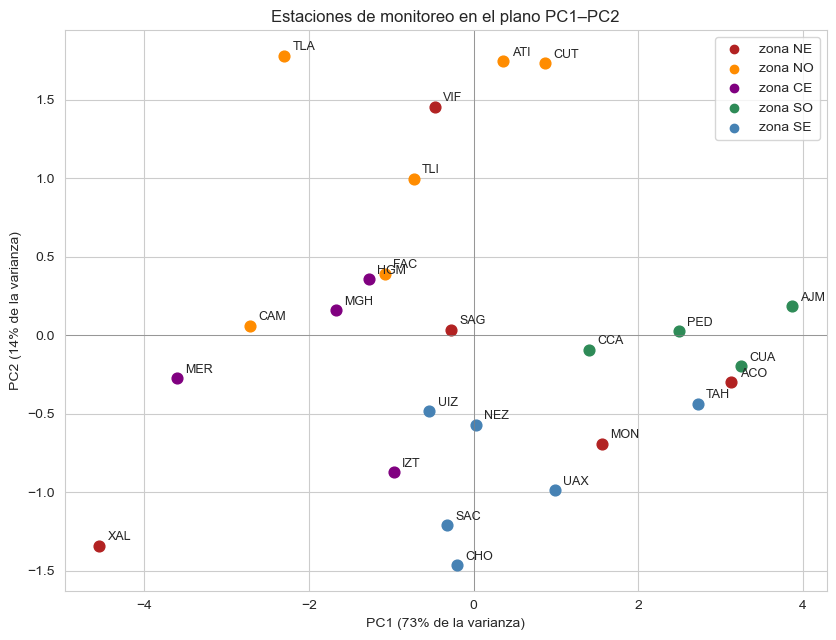

In [ ]:
zonas = [ESTACIONES.get(e, (e, "?"))[1] for e in matriz.index]
colores = {"NE": "firebrick", "NO": "darkorange", "CE": "purple",
           "SO": "seagreen", "SE": "steelblue", "?": "gray"}
plt.figure(figsize=(8.5, 6.5))
for (est, fila), z in zip(pd.DataFrame(Y_propio, index=matriz.index).iterrows(), zonas):
    plt.scatter(fila[0], fila[1], color=colores[z], s=60)
    plt.annotate(est, (fila[0], fila[1]), textcoords="offset points",
                 xytext=(6, 4), fontsize=9)
for z, c in colores.items():
    if z in zonas: plt.scatter([], [], color=c, label=f"zona {z}")
plt.axhline(0, color="gray", lw=.5); plt.axvline(0, color="gray", lw=.5)
plt.xlabel(f"PC1 ({var_exp[0]:.0%} de la varianza)")
plt.ylabel(f"PC2 ({var_exp[1]:.0%} de la varianza)")
plt.title("Estaciones de monitoreo en el plano PC1–PC2")
plt.legend(); plt.tight_layout(); plt.show()

**Interpretación.** La primera componente (PC1, ~73 % de la varianza) **no** representa un "nivel general" de contaminación, sino que opone dos familias químicas: los **contaminantes primarios** —CO, NO, NO$_2$ y NO$_x$— cargan con signo negativo, mientras que el **ozono** (O$_3$) carga con signo positivo. Por eso PC1 separa las estaciones dominadas por tráfico e industria del nororiente y el centro (Xalostoc, San Agustín, con PC1 muy negativo) de las del surponiente elevado y arbolado, con régimen dominado por ozono secundario (Ajusco, Cuajimalpa, Pedregal, con PC1 positivo) —el fenómeno clásico del Valle de México, donde los precursores se transportan con el viento y el O$_3$ se forma corriente abajo. La segunda componente (PC2, ~14 %) está dominada casi por completo por el **SO$_2$** y aísla el corredor industrial del norte (Tlalnepantla, Cuautitlán, Atizapán). Conviene aclarar que el **PM (PM$_{10}$ y PM$_{2.5}$) no entró en este PCA**: el filtro de cobertura lo descartó por datos insuficientes, de modo que el análisis se hizo solo con los seis contaminantes gaseosos. Por último, aunque el plano PC1–PC2 ya resume cerca del 87 % de la varianza, alcanzar el **90 % requiere tres componentes**.

## 10. Escalamiento Multidimensional (Unidad II)

Misma pregunta que el PCA pero desde las **relaciones** entre estaciones: el MDS construye una representación 2-D a partir de la descomposición eigenvectorial de $XX^T$ (apuntes y Práctica 5):

$$XX^T = Q\Lambda Q^{-1} = (Q\sqrt{\Lambda}^{\,T})(\sqrt{\Lambda}\,Q^T) \qquad\Rightarrow\qquad Y = Q_q\sqrt{\Lambda_q}^{\,T}$$

Se compara la implementación propia con `sklearn.manifold.MDS` y se evalúa la calidad con la gráfica $\Delta d = d^y - d^x$ contra $d^x$ (la distorsión de cada distancia entre pares), exactamente como en la Práctica 5.

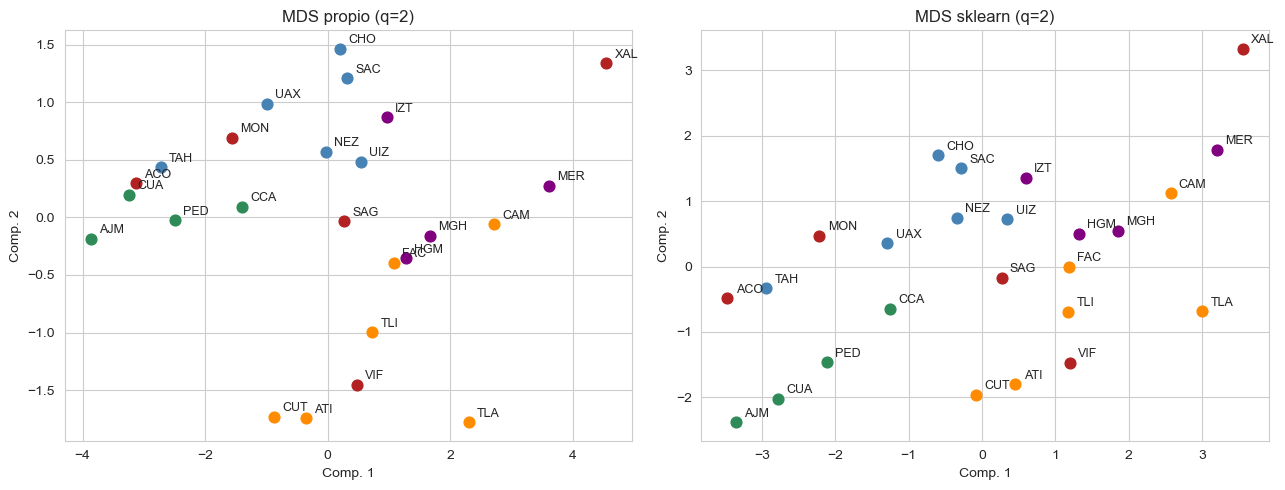

In [ ]:
from sklearn.manifold import MDS
from scipy.spatial.distance import pdist

# --- MDS propio (descomposición de XX^T sobre datos centrados) ---
Xc = X_std - X_std.mean(axis=0)
B = Xc @ Xc.T
vals, vecs = np.linalg.eigh(B)
orden = np.argsort(vals)[::-1]
vals, vecs = vals[orden], vecs[:, orden]
qm = 2
Y_mds = vecs[:, :qm] @ np.diag(np.sqrt(np.maximum(vals[:qm], 0)))

# --- MDS de sklearn ---
mds_sk = MDS(n_components=2, normalized_stress=False, random_state=0)
Y_mds_sk = mds_sk.fit_transform(X_std)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, Y, titulo in [(axes[0], Y_mds, "MDS propio (q=2)"),
                      (axes[1], Y_mds_sk, "MDS sklearn (q=2)")]:
    for i, est in enumerate(matriz.index):
        z = ESTACIONES.get(est, (est, "?"))[1]
        ax.scatter(Y[i, 0], Y[i, 1], color=colores[z], s=60)
        ax.annotate(est, (Y[i, 0], Y[i, 1]), textcoords="offset points",
                    xytext=(6, 4), fontsize=9)
    ax.set_title(titulo); ax.set_xlabel("Comp. 1"); ax.set_ylabel("Comp. 2")
plt.tight_layout(); plt.show()

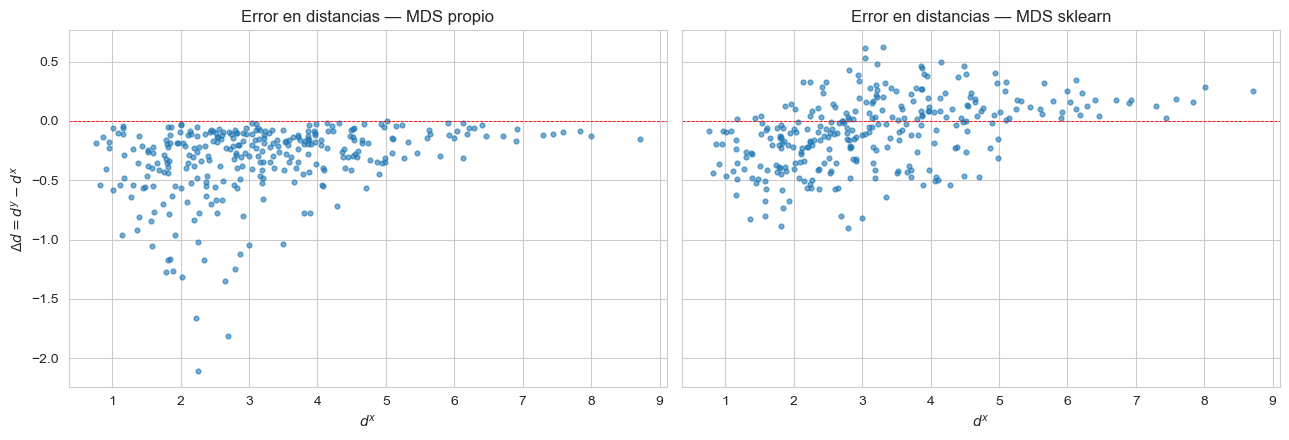

In [ ]:
dx = pdist(X_std)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, Y, titulo in [(axes[0], Y_mds, "MDS propio"), (axes[1], Y_mds_sk, "MDS sklearn")]:
    dy = pdist(Y)
    ax.scatter(dx, dy - dx, s=12, alpha=.6)
    ax.axhline(0, color="r", lw=.6, ls="--")
    ax.set_xlabel("$d^x$"); ax.set_title(f"Error en distancias — {titulo}")
axes[0].set_ylabel(r"$\Delta d = d^y - d^x$")
plt.tight_layout(); plt.show()

**Interpretación.** El MDS propio reproduce la misma estructura de agrupamiento por zonas que el PCA —como vimos en clase, el MDS aplicado a una matriz de características es idéntico al PCA salvo rotaciones/reflexiones—, lo que valida la implementación. En la gráfica de error, $\Delta d \leq 0$ siempre para el MDS espectral: al proyectar se pierden dimensiones y las distancias solo pueden encogerse; las distancias grandes (estaciones muy distintas) son las que más se distorsionan. El MDS de `sklearn` (SMACOF, iterativo) reparte el error de forma más simétrica alrededor de cero porque minimiza el *stress* directamente.

## 11. Correlación (Unidad III)

### 11.1 Pearson, Spearman y Kendall

Sobre la tabla horaria de la estación principal (contaminantes + meteorología) se calculan los tres coeficientes del temario: **Pearson** $r$ (relación *lineal*), **Spearman** $\rho$ (relación *monótona*, basada en rangos, robusta a outliers) y **Kendall** $\tau$ (concordancia de pares, también de rangos).

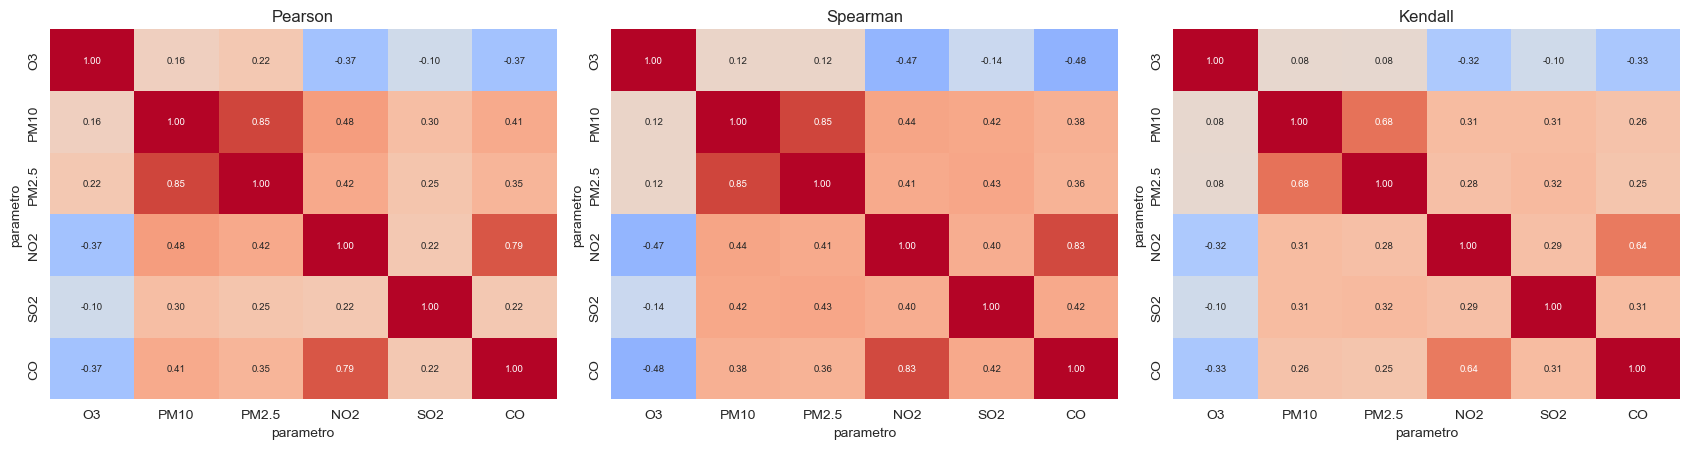

In [ ]:
sub = limpio[VARS].dropna()
metodos = ["pearson", "spearman", "kendall"]
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
matrices = {}
for ax, met in zip(axes, metodos):
    m = sub.corr(method=met)
    matrices[met] = m
    sns.heatmap(m, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
                ax=ax, cbar=False, annot_kws={"size": 7})
    ax.set_title(met.capitalize())
plt.tight_layout(); plt.show()

### 11.2 Efecto de los outliers en la correlación

En la sección 5.3 conservamos deliberadamente los episodios extremos. Aquí se cuantifica su efecto repitiendo el experimento de la Práctica 2: comparar la correlación de PM$_{10}$ con el resto de variables **antes y después** de remover sus outliers (regla IQR).

In [ ]:
o_pm, lo, hi = outliers_iqr(sub["PM10"])
sub_sin = sub[(sub["PM10"] >= lo) & (sub["PM10"] <= hi)]
print(f"Outliers de PM10 removidos: {len(sub) - len(sub_sin):,} de {len(sub):,} registros")

comp = pd.DataFrame({
    "Pearson con outliers": sub.corr()["PM10"],
    "Pearson sin outliers": sub_sin.corr()["PM10"],
    "Spearman con outliers": sub.corr(method="spearman")["PM10"],
}).drop("PM10").round(3)
comp["Δ Pearson"] = (comp["Pearson sin outliers"] - comp["Pearson con outliers"]).round(3)
print("\n" + comp.to_string())

Outliers de PM10 removidos: 147 de 6,474 registros

           Pearson con outliers  Pearson sin outliers  Spearman con outliers  Δ Pearson
parametro                                                                              
O3                        0.160                 0.188                  0.116      0.028
PM2.5                     0.845                 0.840                  0.847     -0.005
NO2                       0.482                 0.460                  0.438     -0.022
SO2                       0.296                 0.271                  0.425     -0.025
CO                        0.408                 0.371                  0.378     -0.037


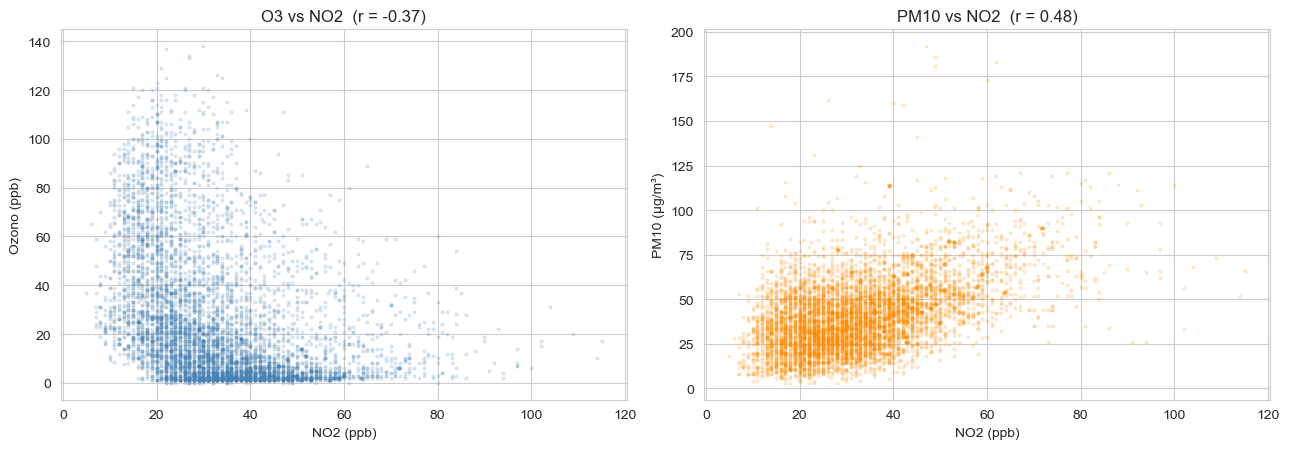

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
axes[0].scatter(sub["NO2"], sub["O3"], s=4, alpha=.15, color="steelblue")
axes[0].set_xlabel(ETIQUETAS["NO2"]); axes[0].set_ylabel(ETIQUETAS["O3"])
axes[0].set_title(f"O3 vs NO2  (r = {sub['O3'].corr(sub['NO2']):.2f})")
axes[1].scatter(sub["NO2"], sub["PM10"], s=4, alpha=.15, color="darkorange")
axes[1].set_xlabel(ETIQUETAS["NO2"]); axes[1].set_ylabel(ETIQUETAS["PM10"])
axes[1].set_title(f"PM10 vs NO2  (r = {sub['PM10'].corr(sub['NO2']):.2f})")
plt.tight_layout(); plt.show()

**Interpretation: correlation and causality (topic 3.3).** O3 and NO2 show a strong negative correlation because NO2 is a precursor consumed in the photochemical reaction producing O3. PM10 and NO2 are positively correlated because both peak during morning rush hour driven by the same cause (traffic), not by each other — a confounding case analogous to HR-IBB in Practice 2. Spearman being close to Pearson indicates approximately monotone relationships; where Pearson shifts notably after removing PM10 outliers (section 11.2), the linear correlation partly depended on extreme episodes. The lesson of Unit III: the correlation matrix describes *association*, and the causal mechanism must be argued from domain knowledge.

### 11.3 Correlación no lineal: prueba chi-cuadrada de independencia (tema 3.2)

**Hipótesis.** $H_0$: la categoría diaria de calidad del aire por O$_3$ es independiente de la temporada climática. $H_1$: existe dependencia.

Se categoriza cada día por su **máximo horario de O$_3$** según los puntos de corte del índice AIRE Y SALUD (variable ordinal: Buena ≤ 58 ppb < Aceptable ≤ 90 < Mala ≤ 135 < Muy mala) y por su **temporada** (nominal: seca-fría nov–feb, seca-caliente mar–may, lluvias jun–oct, la regionalización que usa la SEDEMA). El estadístico se calcula **con la fórmula de clase** $\chi^2 = \sum_{ij} (O_{ij} - E_{ij})^2 / E_{ij}$, con $E_{ij} = (\text{fila}_i \times \text{col}_j)/n$, y se verifica con `scipy.stats.chi2_contingency`.

In [ ]:
from scipy.stats import chi2 as chi2_dist, chi2_contingency

dia_max = limpio["O3"].resample("D").max()
cat = dia_max.apply(categoria_o3)
temp = pd.Series(dia_max.index.map(temporada), index=dia_max.index)
tabla = pd.crosstab(cat, temp).reindex(
    index=[c for c in ["Buena","Aceptable","Mala","Muy mala"] if c in set(cat.dropna())],
    columns=["Seca-fría","Seca-caliente","Lluvias"]).fillna(0).astype(int)
print("Tabla de contingencia (días):\n")
print(tabla.to_string())

chi2_obs, gl, E_esp = chi_cuadrada(tabla.values)        # fórmula de clase
valor_critico = chi2_dist.ppf(0.95, gl)
p_valor = 1 - chi2_dist.cdf(chi2_obs, gl)
print(f"\nχ² observado = {chi2_obs:.2f}   gl = {gl}   "
      f"valor crítico (α=0.05) = {valor_critico:.2f}   p-valor = {p_valor:.2e}")

# Verificación con scipy
chi2_sp, p_sp, gl_sp, _ = chi2_contingency(tabla.values)
print(f"Verificación scipy: χ² = {chi2_sp:.2f}, p = {p_sp:.2e}, gl = {gl_sp}")

print("\nFrecuencias esperadas bajo independencia:")
print(pd.DataFrame(E_esp, index=tabla.index, columns=tabla.columns).round(1).to_string())

if chi2_obs > valor_critico:
    print("\nConclusión: se RECHAZA H0 — la calidad del aire por O3 depende de la temporada.")
else:
    print("\nConclusión: no se rechaza H0 al 5% de significancia.")

Tabla de contingencia (días):

col_0      Seca-fría  Seca-caliente  Lluvias
O3                                          
Buena             60             36       73
Aceptable         31             30       40
Mala              35             29       44
Muy mala           1              1        0

χ² observado = 4.12   gl = 6   valor crítico (α=0.05) = 12.59   p-valor = 6.60e-01
Verificación scipy: χ² = 4.12, p = 6.60e-01, gl = 6

Frecuencias esperadas bajo independencia:
col_0      Seca-fría  Seca-caliente  Lluvias
O3                                          
Buena           56.5           42.7     69.8
Aceptable       33.8           25.5     41.7
Mala            36.1           27.3     44.6
Muy mala         0.7            0.5      0.8

Conclusión: no se rechaza H0 al 5% de significancia.


**Interpretación.** Con los datos reales de la estación Merced, el estadístico observado ($\chi^2 = 4.12$) **no** supera el valor crítico ($12.59$) y el $p$-valor es alto ($p \approx 0.66$): **no se rechaza $H_0$**. Es decir, en esta estación la categoría diaria de calidad del aire por O$_3$ se comporta como **independiente** de la temporada. La lectura se confirma comparando las frecuencias observadas con las esperadas bajo independencia: son muy parecidas en las tres temporadas (los días *Buena/Aceptable/Mala* se reparten de forma similar entre seca-fría, seca-caliente y lluvias), sin la concentración marcada de días malos en seca-caliente que indicaría dependencia. El resultado puede sorprender, porque la estacionalidad del ozono está bien documentada; la explicación es que **Merced es una estación céntrica**, cuyo ozono no se concentra por temporada de forma tan marcada como el del surponiente elevado, y que la prueba **categórica** (variable ordinal de cuatro niveles contra tres temporadas) **pierde potencia** frente a la señal continua. De hecho, las técnicas continuas de este mismo proyecto —el ciclo anual y la correlación O$_3$↔temperatura— sí reflejan la estacionalidad; es la versión categórica, en esta estación, la que no alcanza significancia. Esto motiva la prueba por zonas que se plantea en el trabajo futuro: en las estaciones de alto ozono del sur, el patrón estacional sí debería manifestarse en la tabla.

## 12. Exportación de resultados para el dashboard

El tablero de Streamlit (Unidad II, tema 2.4) debe mostrar **los mismos resultados de este notebook**, no análisis distintos. Por ello aquí se exportan los productos del análisis a `datos/procesados/`: la serie horaria limpia de la estación principal, los agregados diarios de todas las estaciones, las coordenadas PC1–PC2 y las cargas del PCA, y un resumen de parámetros.

In [ ]:
# 1) Serie horaria limpia de la estación principal
limpio.rename_axis("fecha").to_csv(RUTA_PROC / "horario_principal.csv")

# 2) Agregados diarios de TODAS las estaciones (promedio y máximo)
diario = (datos.dropna(subset=["valor"])
               .assign(dia=lambda d: d["fecha"].dt.floor("D"))
               .groupby(["dia", "estacion", "parametro"])["valor"]
               .agg(promedio="mean", maximo="max").reset_index())
diario.to_csv(RUTA_PROC / "diario_todas.csv", index=False)

# 3) Resultados del PCA (coordenadas, zonas y cargas)
pca_out = pd.DataFrame(Y_propio[:, :2], index=matriz.index, columns=["PC1", "PC2"])
pca_out["nombre"] = [ESTACIONES.get(e, (e, "?"))[0] for e in pca_out.index]
pca_out["zona"]   = [ESTACIONES.get(e, (e, "?"))[1] for e in pca_out.index]
pca_out.rename_axis("estacion").to_csv(RUTA_PROC / "pca_estaciones.csv")
cargas.iloc[:, :4].rename_axis("parametro").to_csv(RUTA_PROC / "cargas_pca.csv")

# 4) Resumen de parámetros del análisis
resumen = {"estacion_principal": ESTACION,
           "nombre_estacion": nombre_est,
           "zona": zona_est,
           "varianza_pc1": round(float(var_exp[0]), 4),
           "varianza_pc2": round(float(var_exp[1]), 4),
           "q_90": int(q_90),
           "chi2": round(float(chi2_obs), 2),
           "chi2_p": float(p_valor),
           "anios": sorted(set(limpio.index.year.tolist()))}
(RUTA_PROC / "resumen.json").write_text(json.dumps(resumen, indent=2, ensure_ascii=False))

print("Archivos exportados a datos/procesados/:")
for f in sorted(RUTA_PROC.iterdir()):
    print(f"  {f.name:>24}  ({f.stat().st_size/1e6:.2f} MB)")

Archivos exportados a datos/procesados/:
            cargas_pca.csv  (0.00 MB)
          diario_todas.csv  (2.46 MB)
     horario_principal.csv  (1.05 MB)
        pca_estaciones.csv  (0.00 MB)
              resumen.json  (0.00 MB)


## 13. Conclusiones

1. **Preprocesamiento (objetivo 1).** Las bases de la RAMA requieren un tratamiento cuidadoso: códigos $-99$, horas en formato 01–24 y huecos de sensor. La interpolación lineal acotada a huecos cortos imputó los faltantes sin deformar las distribuciones (verificado con densidades antes/después), y la inspección con las reglas de $2\sigma$ e IQR mostró que los valores extremos restantes son episodios reales de contaminación —outliers con causa física que decidimos conservar en las series y cuyo efecto se cuantificó por separado.
2. **Filtrado (objetivo 2).** Los tres filtros de clase, implementados con sus fórmulas, separan con éxito la variación de mediano plazo del ciclo diurno y el ruido; el de medianas resultó el más robusto ante episodios extremos y el exponencial el de mayor suavidad y retraso.
3. **Análisis espectral (objetivo 3).** La transformada del seno y coseno identificó objetivamente las componentes que el EDA sugería: el ciclo diurno de 24 h (y su armónico de 12 h) domina la serie horaria de O$_3$, y la modulación estacional domina la serie diaria. La comparación entre la reconstrucción del enunciado (con $|B_i|$) y la transformada inversa con fase mostró que amplitud y frecuencia no bastan: la fase determina *cuándo* ocurre cada cresta, y conservándola la reconstrucción con unas cuantas componentes más la tendencia explica la mayor parte de la varianza — la dinámica del ozono es esencialmente periódica.
4. **Proyecciones (objetivo 4).** El PCA propio (verificando $C\cdot E = \lambda\cdot E$ y coincidiendo con `sklearn`) y el MDS espectral coinciden en agrupar a las estaciones por zona: el plano PC1–PC2 separa el nororiente con altos contaminantes primarios del surponiente con régimen dominado por ozono, con ~90 % de la varianza en pocas componentes.
5. **Correlación (objetivo 5).** Pearson, Spearman y Kendall coinciden en las asociaciones principales (O$_3$↑ con temperatura↑ y humedad↓; PM con viento); el contraste con/sin outliers mostró cuánto de la correlación lineal descansa en los episodios extremos, y la discusión de causalidad identificó a la radiación solar como variable confusora. La prueba $\chi^2$, en cambio, **no rechazó** la independencia entre la categoría de calidad del aire por ozono y la temporada en la estación central (Merced: $\chi^2 = 4.12 < 12.59$, $p \approx 0.66$): con esta prueba categórica, y en esta estación, la dependencia estacional no alcanza significancia, aunque las técnicas continuas del proyecto sí muestran la estacionalidad del ozono. Es un resultado que invita al análisis crítico —potencia de la prueba, elección de la estación y de las categorías—, no un fracaso.
6. **Tablero (objetivo 6).** Todos los productos del análisis se exportaron a `datos/procesados/` y alimentan el dashboard de Streamlit (`streamlit_app.py`), que presenta exactamente estos resultados con filtros por estación, contaminante, año y tipo de filtro.

**Trabajo futuro.** Extender el periodo a 3+ años para resolver con precisión la componente anual del espectro, e incorporar la prueba chi-cuadrada por zonas de la ciudad.

## Referencias

* Runkler, T. (2020). *Data Analytics: Models and Algorithms for Intelligent Data Analysis*. Springer.
* Bruce, P. & Bruce, A. (2020). *Practical Statistics for Data Scientists*. O'Reilly.
* Secretaría del Medio Ambiente CDMX. *Sistema de Monitoreo Atmosférico de la Ciudad de México*. https://aire.cdmx.gob.mx
* NOM-172-SEMARNAT. *Lineamientos para la obtención y comunicación del Índice de Calidad del Aire y Riesgos a la Salud.*
* Apuntes y prácticas del curso *Analítica y Visualización de Datos* (LCD2020), ESCOM-IPN, semestre 2026-2.